In [1]:
from pathlib import Path
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from mne import io
from mne import Epochs
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import balanced_accuracy_score
from collections import Counter
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from braindecode.models import EEGNetv4
import lightgbm as lgb

In [2]:
import torch
print(torch.__version__)
print("MPS available?", torch.backends.mps.is_available())

2.7.1
MPS available? True


### Config — paths & processing constants  

All hard-coded parameters live in one place so you (or a colleague) can
re-run the notebook on another machine by editing a single cell.

* **paths** – BIDS root and sub-folders inside `derivatives/`
* **data**  – recording constants reused later (montage, sfreq, etc.)

In [3]:
CONFIG = dict(
    paths = dict(
        bids_root   = Path("../bids_dataset"),
        annot_dir   = Path("../bids_dataset/derivatives/annotated/sub-01/ses-third/eeg"),
    ),
    data = dict(
        sfreq       = 250.0,                      # Hz
        eeg_ch      = ['F3', 'F4', 'C3', 'C4', 'P3',  'P4', 'Pz', 'Oz'],
        n_blocks    = 1,
        selected_runs = [1],
    ),
    model = dict(
        cv_folds    = 5,            # number of StratifiedGroupKFold splits
    ),
)

# create necessary directories
for path in CONFIG["paths"].values():
    if path.suffix == "":  # skip CSV
        path.mkdir(parents=True, exist_ok=True)

print("Notebook-09 CONFIG defined and directories created 🚀")

Notebook-09 CONFIG defined and directories created 🚀


## 1. Dataset Structure

In this section, we load all annotated FIF blocks and verify the integrity and shape of the data. Each block is read from disk with its pre-processed channels and annotations, ensuring all expected blocks (0–19) are available and correctly formatted.

We check:

- That all blocks (0–19) are loaded with the correct number of channels and samples.
- The consistency of data shape and duration across blocks.

In [4]:
# Load only selected annotated EEG blocks into a dictionary
raws = {}
selected_runs = CONFIG['data']['selected_runs']

for block_id in selected_runs:
    fname = CONFIG['paths']['annot_dir'] / f'sub-01_ses-third_task-sunimagery_run-{block_id:02d}_icaclean_annot.fif'
    raws[block_id] = io.read_raw_fif(fname, preload=True, verbose='ERROR')
    data = raws[block_id].get_data()
    print(f"Loaded block {block_id:02d}: {data.shape[0]} channels × {data.shape[1]} samples, {raws[block_id].times[-1]:.2f} s")

# Quick check: all expected blocks loaded
assert set(raws.keys()) == set(selected_runs), "Mismatch in number of blocks loaded"

# Print a short summary for confirmation
print(f"\nSelected {len(raws)} blocks loaded. Example block keys: {list(raws.keys())[:4]}")


Loaded block 01: 9 channels × 86001 samples, 344.00 s

Selected 1 blocks loaded. Example block keys: [1]


In [5]:
eeg_ch_names = CONFIG['data']['eeg_ch']
bad_chs = {}
eeg_ch_names = [ch for ch in eeg_ch_names if ch not in bad_chs]

first_raw = next(iter(raws.values()))  # generic way to access the first loaded run
all_ch_names = first_raw.ch_names

eeg_picks = [all_ch_names.index(ch) for ch in eeg_ch_names]
n_channels = len(eeg_picks)

print("EEG picks:", eeg_picks)
print("EEG channel names:", [all_ch_names[i] for i in eeg_picks])
print("Number of EEG channels:", n_channels)


EEG picks: [0, 1, 2, 3, 4, 5, 6, 7]
EEG channel names: ['F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'Pz', 'Oz']
Number of EEG channels: 8


In [6]:
# Inspect annotations from block 1
raw = next(iter(raws.values()))
annots = raw.annotations

print("Annotation descriptions:")
print(np.unique(annots.description))

print("\nFirst few annotations:")
for onset, duration, desc in zip(annots.onset[:10], annots.duration[:10], annots.description[:10]):
    print(f"Onset: {onset:.2f} s | Duration: {duration:.2f} s | Description: {desc}")


Annotation descriptions:
['rest_block' 'sun_block']

First few annotations:
Onset: 15.21 s | Duration: 6.35 s | Description: sun_block
Onset: 21.56 s | Duration: 5.08 s | Description: rest_block
Onset: 26.64 s | Duration: 6.35 s | Description: sun_block
Onset: 33.00 s | Duration: 5.08 s | Description: rest_block
Onset: 38.08 s | Duration: 6.35 s | Description: sun_block
Onset: 44.43 s | Duration: 5.08 s | Description: rest_block
Onset: 49.51 s | Duration: 6.35 s | Description: sun_block
Onset: 55.86 s | Duration: 5.08 s | Description: rest_block
Onset: 60.94 s | Duration: 6.35 s | Description: sun_block
Onset: 67.29 s | Duration: 5.08 s | Description: rest_block


In [9]:
# Sliding Window Extraction for sun/rest blocks

window_length_s = 2.0
window_hop_s = 0.5
sfreq = raw.info['sfreq']
window_samples = int(window_length_s * sfreq)
window_hop_samples = int(window_hop_s * sfreq)

eeg_picks = mne.pick_types(raw.info, eeg=True)

all_windows = []

# Generate window centers along time
t_centers = np.arange(window_length_s/2, raw.times[-1] - window_length_s/2, window_hop_s)

for t_center in t_centers:
    # Check if this window is within a valid annotation
    label = None
    for ann in raw.annotations:
        if ann["onset"] <= t_center < ann["onset"] + ann["duration"]:
            label = ann["description"]
            break
    if label is None:
        continue  # window outside annotation

    # Calculate window start
    t_start = t_center - window_length_s/2
    start_sample = int(t_start * sfreq)
    if start_sample < 0 or (start_sample + window_samples) > raw.n_times:
        continue

    all_windows.append({
        "start_sample": start_sample,
        "center_sample": int(t_center * sfreq),
        "label": label,
        "t_center": t_center,
    })

# Check integrity
print("Checking window shapes...")
bad_windows = 0
for w in all_windows:
    seg = raw.get_data(picks=eeg_picks,
                       start=w['start_sample'],
                       stop=w['start_sample'] + window_samples)
    if seg.shape != (len(eeg_picks), window_samples):
        print(f"⚠️ Bad window at t={w['t_center']:.2f}s")
        bad_windows += 1

windows_df = pd.DataFrame(all_windows)
print(f"\n✅ Extracted {len(windows_df)} valid windows")
print(f"🧠 Labels: {windows_df['label'].value_counts().to_dict()}")


Checking window shapes...

✅ Extracted 655 valid windows
🧠 Labels: {'sun_block': 367, 'rest_block': 288}


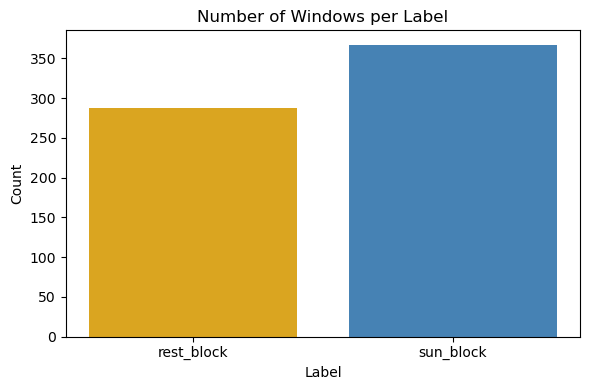

🧠 Window label distribution:
 label
rest_block    288
sun_block     367
Name: count, dtype: int64


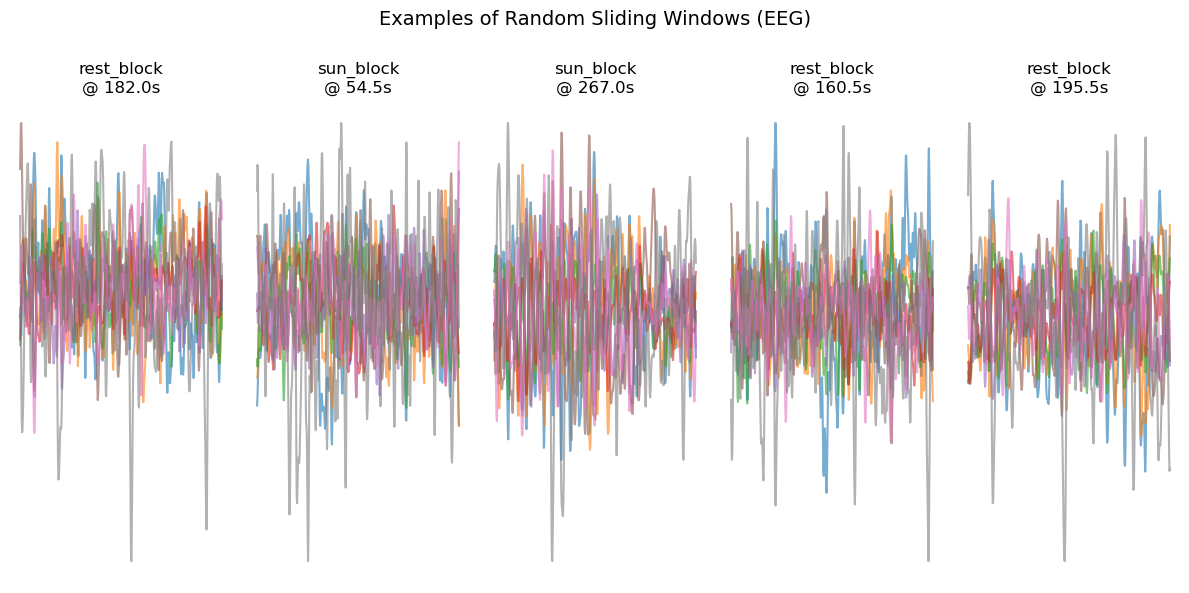

In [11]:
# 1.3. Window/Label Distribution Summary & Visual QC

import matplotlib.pyplot as plt
import numpy as np

# --- Distribuição de labels (sun/rest) ---
label_counts = windows_df['label'].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(label_counts.index, label_counts.values, color=["goldenrod", "steelblue"])
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Number of Windows per Label')
plt.tight_layout()
plt.show()

print("🧠 Window label distribution:\n", label_counts)

# --- Quick plot of 5 random windows for visual QC ---
np.random.seed(42)
sample_idx = np.random.choice(len(windows_df), 5, replace=False)

plt.figure(figsize=(12, 6))
for i, idx in enumerate(sample_idx, 1):
    row = windows_df.iloc[idx]
    start = row['start_sample']
    seg = raw.get_data(picks=eeg_picks,
                       start=start,
                       stop=start + window_samples)
    plt.subplot(1, 5, i)
    plt.plot(seg.T, alpha=0.6)
    plt.title(f"{row['label']}\n@ {row['t_center']:.1f}s")
    plt.axis('off')

plt.suptitle("Examples of Random Sliding Windows (EEG)", fontsize=14)
plt.tight_layout()
plt.show()


## 2. Labels and Groups

We extract sliding 2 s windows (with 0.5 s overlap) across each block, skipping intervals labeled as BAD_intro. For each window, the label is set to the most recent phrase marker preceding the window center.

We create a DataFrame indexing every window by:

- Block of origin (block_id)
- Window start and center (in samples and seconds)
- Assigned phrase label (1–6)

We confirm:

- The total number of windows and their distribution across blocks.
- The distribution of labels for quality control.

Counts of each label:
label
rest_block    288
sun_block     367
Name: count, dtype: int64


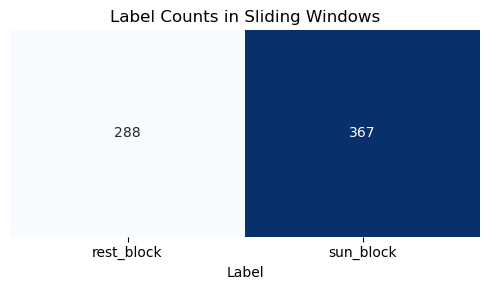

✅ Both labels present.


In [49]:
# 2b. Confirming Labels

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize count of windows per label (sun/rest)
label_counts = windows_df["label"].value_counts().sort_index()

print("Counts of each label:")
print(label_counts)

# Visualize as simple 1D heatmap
plt.figure(figsize=(5, 3))
sns.heatmap(label_counts.to_frame().T, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Label Counts in Sliding Windows")
plt.xlabel("Label")
plt.yticks([])  # remove y-axis index
plt.tight_layout()
plt.show()

# Verify: both labels are present
n_labels = label_counts.shape[0]
if n_labels < 2:
    print("⚠️ Warning: Only one label present in dataset.")
else:
    print("✅ Both labels present.")


## 3. Split Strategy

In this section, we use StratifiedGroupKFold to partition the extracted sliding windows into training, validation, and test splits. This strategy preserves the balance of phrase labels across splits while ensuring that all windows from a given block (recording session) remain grouped together. This is essential to avoid data leakage and to maintain a realistic out-of-sample evaluation.

We proceed as follows:

- The group column (block index) is used to keep all windows from the same block in a single split.
- The label column ensures each split maintains a similar class distribution.
- We assign split labels (train, val, test) to each window in the DataFrame for downstream processing.
- We visually inspect the label distribution within each split to verify balance and exclusivity.

This approach ensures robust, reproducible model evaluation without temporal or subject leakage.

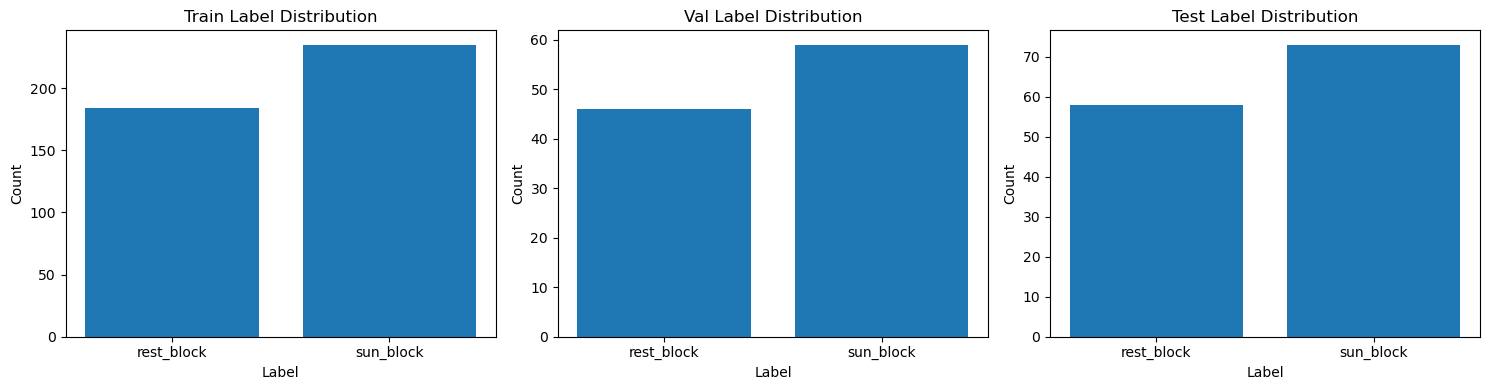

In [50]:
# 3. Split Strategy: Stratified ShuffleSplit (no groups)

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# a) Labels
y = windows_df["label"].values

# b) Initial split: trainval vs test
trainval_idx, test_idx = train_test_split(
    windows_df.index,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# c) Secondary split: train vs validation
y_trainval = y[trainval_idx]
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=0.2,
    stratify=y_trainval,
    random_state=43
)

# d) Assign splits to DataFrame
windows_df["split"] = "train"
windows_df.loc[val_idx,  "split"] = "val"
windows_df.loc[test_idx, "split"] = "test"

# e) Visualize label balance per split
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, split in zip(axes, ["train", "val", "test"]):
    counts = (windows_df[windows_df.split == split]["label"]
              .value_counts()
              .sort_index())
    ax.bar(counts.index, counts.values)
    ax.set_title(f"{split.capitalize()} Label Distribution")
    ax.set_xlabel("Label")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


## 4. Normalization (Z-Score)

In this section, we compute per-channel mean and standard deviation using only the training windows. We then apply a z-score normalization to all windows, using these training-derived parameters for the validation and test sets as well.

**Procedure:**

- Select only windows assigned to the train split from the DataFrame.
- For each training window, load the corresponding EEG segment and concatenate them across all training blocks.
- Compute the mean and standard deviation for each channel, resulting in one mean and one std per channel.
- Normalize each window (across all splits) by subtracting the training mean and dividing by the training std, channel-wise.

This approach ensures that no information from the validation or test sets "leaks" into the normalization parameters, preserving a fair model evaluation.

We check the resulting normalized values for correctness by inspecting their distributions.

In [15]:
print("Channel names:", next(iter(raws.values())).ch_names)
print("Channel types:", next(iter(raws.values())).get_channel_types())

Channel names: ['F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'Pz', 'Oz', 'stim']
Channel types: ['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'stim']


In [16]:
# eeg_picks = [i for i, t in enumerate(raws[0].get_channel_types()) if t == 'eeg']
print("EEG picks:", eeg_picks)
print("Number of EEG channels:", len(eeg_picks))

EEG picks: [0 1 2 3 4 5 6 7]
Number of EEG channels: 8


In [18]:
# 4a. Compute Per-Channel Mean and Std on Training Windows

# Parameters
n_channels = len(eeg_picks)
window_samples = int(2.0 * sfreq)

# Filter only training windows
train_df = windows_df[windows_df['split'] == 'train']

# Extract EEG segments: (channels x samples x windows)
train_segments = []
for i, row in train_df.iterrows():
    seg = raw.get_data(picks=eeg_picks,
                       start=int(row['start_sample']),
                       stop=int(row['start_sample']) + window_samples)
    train_segments.append(seg)

train_data = np.stack(train_segments, axis=2)  # shape: channels x samples x windows

# Reshape to (channels, total_samples)
train_data_reshaped = train_data.reshape(n_channels, -1)

# Calculate mean and std per channel
channel_mean = train_data_reshaped.mean(axis=1)  # (n_channels,)
channel_std = train_data_reshaped.std(axis=1)

print("✅ Training set channel means (µV):\n", channel_mean)
print("📉 Channel stds (µV):\n", channel_std)
print("🧠 Shape (channels x samples x windows):", train_data.shape)


✅ Training set channel means (µV):
 [-1.70477699e-10  1.08355410e-10 -8.67445564e-11 -1.40817538e-10
 -8.74044058e-12  6.56078264e-11 -1.41624454e-11  2.46979452e-10]
📉 Channel stds (µV):
 [1.11104923e-07 9.71714396e-08 6.90409974e-08 6.37073210e-08
 7.18748371e-08 9.61268276e-08 8.48649583e-08 1.54932278e-07]
🧠 Shape (channels x samples x windows): (8, 500, 419)


In [19]:
# 4b. Apply Z-Score Normalization to All Windows

# Function for fast normalization
def normalize_segment(seg, mean, std):
    # seg: shape (channels, samples)
    return (seg - mean[:, None]) / std[:, None]

# Example: apply normalization to first 5 windows
for idx in range(5):
    row = windows_df.iloc[idx]
    seg = raw.get_data(picks=eeg_picks,
                       start=int(row['start_sample']),
                       stop=int(row['start_sample']) + window_samples)
    seg_norm = normalize_segment(seg, channel_mean, channel_std)

    print(f"Window {idx} ({row['label']} @ {row['t_center']:.2f}s):")
    print("→ Mean per channel after norm:", seg_norm.mean(axis=1))
    print("→ Std per channel after norm:", seg_norm.std(axis=1))
    print("-" * 40)

Window 0 (sun_block @ 15.50s):
→ Mean per channel after norm: [ 0.00446383 -0.01068478  0.01418544  0.04700794  0.03219389 -0.00724111
  0.01198697 -0.03915881]
→ Std per channel after norm: [1.26449499 1.19240728 1.29197277 1.46066796 1.44128348 1.45150267
 1.14075199 1.23376227]
----------------------------------------
Window 1 (sun_block @ 16.00s):
→ Mean per channel after norm: [ 0.02570075  0.04517504  0.00383261 -0.04620219 -0.01257641 -0.01826124
 -0.0490689   0.01456869]
→ Std per channel after norm: [1.34984409 1.29614939 1.35036943 1.42749441 1.50563954 1.47358457
 1.23176464 1.30708318]
----------------------------------------
Window 2 (sun_block @ 16.50s):
→ Mean per channel after norm: [ 0.02302288 -0.04573318  0.03920884 -0.08213798  0.05477336  0.0031094
  0.05505007 -0.02901764]
→ Std per channel after norm: [1.2879463  1.28741512 1.35575412 1.23455819 1.25885583 1.28278353
 1.17085373 1.35104587]
----------------------------------------
Window 3 (sun_block @ 17.00s):
→

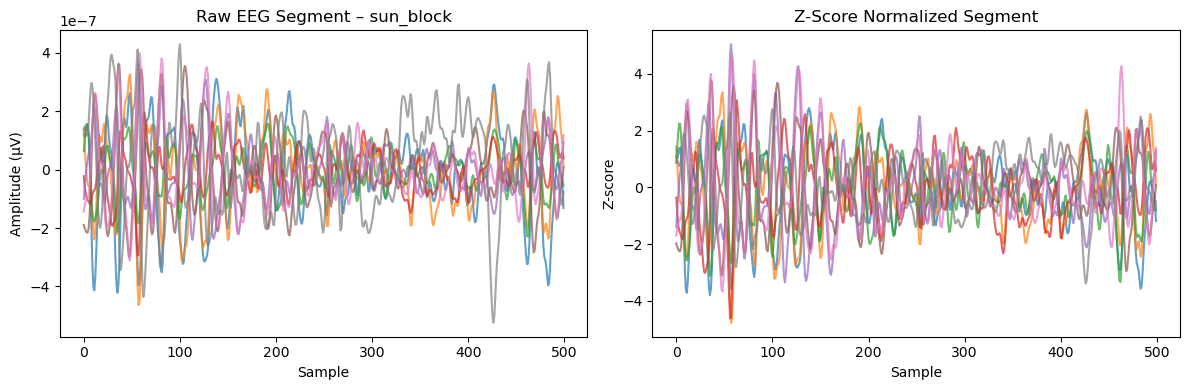

In [21]:
# 4c. Visual Check: Distribution Before/After Normalization

# Select a random training window
rand_idx = train_df.sample(1, random_state=0).index[0]
row = windows_df.loc[rand_idx]

# Extract raw segment
seg = raw.get_data(picks=eeg_picks,
                   start=int(row['start_sample']),
                   stop=int(row['start_sample']) + window_samples)

# Normalize
seg_norm = normalize_segment(seg, channel_mean, channel_std)

# Plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(seg.T, alpha=0.7)
plt.title(f"Raw EEG Segment – {row['label']}")
plt.xlabel("Sample")
plt.ylabel("Amplitude (µV)")

plt.subplot(1, 2, 2)
plt.plot(seg_norm.T, alpha=0.7)
plt.title("Z-Score Normalized Segment")
plt.xlabel("Sample")
plt.ylabel("Z-score")

plt.tight_layout()
plt.show()


## 5. Class Imbalance and Loss Weights

In this section, we address the natural class imbalance present in the dataset: some phrase labels are more frequent than others due to experimental design and windowing strategy.

To ensure that the model does not become biased toward the majority classes, we:

- Compute the frequency of each class in the training split only.
- Calculate inverse-frequency weights so that minority classes receive higher penalty during training.
- Pass these weights to the loss function (e.g., PyTorch’s CrossEntropyLoss), which amplifies the contribution of under-represented classes to the training objective.

We visualize:
- The distribution of class frequencies in the training set.
- The corresponding class weights derived for the loss function.

This approach helps balance the learning process and encourages the model to perform well on all classes, not just the most common ones.

In [ ]:
# 5. Class Imbalance: Compute Class Weights for CrossEntropyLoss

# Get labels from training set
train_labels = windows_df.loc[windows_df["split"] == "train", "label"].values

# Encode labels as integers
label_to_index = {label: idx for idx, label in enumerate(sorted(np.unique(train_labels)))}
index_to_label = {idx: label for label, idx in label_to_index.items()}

# Map labels to integers
y_train_idx = np.array([label_to_index[lbl] for lbl in train_labels])

# Frequencies and weights
classes, counts = np.unique(y_train_idx, return_counts=True)
print("Train set class frequencies:")
for c, n in zip(classes, counts):
    print(f"Label {index_to_label[c]} (index {c}): {n} windows")

# Calculate inverse frequency weights
freqs = counts / counts.sum()
inv_freq = 1.0 / freqs
class_weights = inv_freq / inv_freq.sum() * len(classes)  # sum = number of classes

# PyTorch tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)

print("\nClass weights (for CrossEntropyLoss):", class_weights)
print("Label mapping:", index_to_label)


Train set class frequencies:
Label rest_block (index 0): 184 windows
Label sun_block (index 1): 235 windows

Class weights (for CrossEntropyLoss): [1.12171838 0.87828162]
Label mapping: {0: 'rest_block', 1: 'sun_block'}


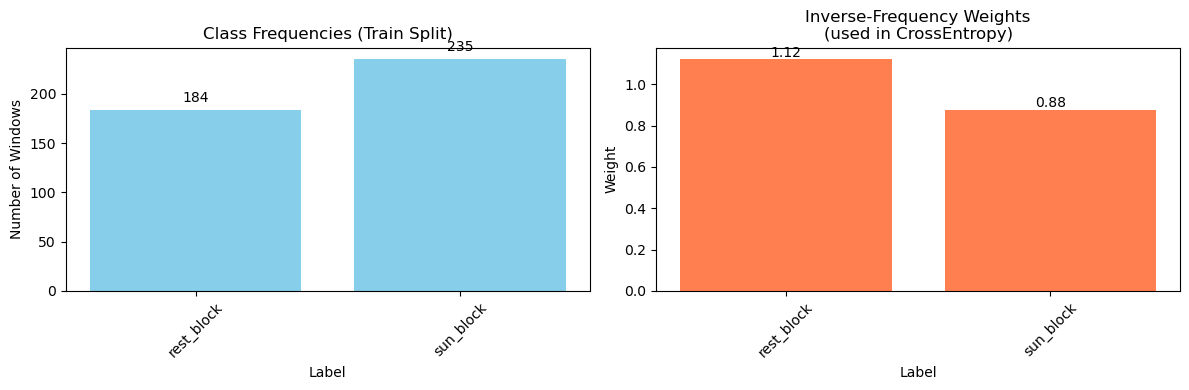

In [ ]:
# Visualize class frequencies and weights (Train Split)

labels = list(index_to_label.keys())      # [0, 1]
label_names = [index_to_label[i] for i in labels]
freqs = counts                            # computed above
weights = class_weights                   # computed above

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Frequencies
axes[0].bar(labels, freqs, color='skyblue')
axes[0].set_title("Class Frequencies (Train Split)")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Number of Windows")
axes[0].set_xticks(labels)
axes[0].set_xticklabels(label_names, rotation=45)
for i, v in enumerate(freqs):
    axes[0].text(labels[i], v + 8, str(v), ha='center')

# Weights
axes[1].bar(labels, weights, color='coral')
axes[1].set_title("Inverse-Frequency Weights\n(used in CrossEntropy)")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Weight")
axes[1].set_xticks(labels)
axes[1].set_xticklabels(label_names, rotation=45)
for i, w in enumerate(weights):
    axes[1].text(labels[i], w + 0.01, f"{w:.2f}", ha='center')

plt.tight_layout()
plt.show()

## 6. EEGNet Modeling Pipeline (PyTorch)

In this section, we prepare the EEG data for deep learning using PyTorch and define the EEGNet model.

**6.1. EEGWindowDataset**

We define a custom `Dataset` class that loads sliding-window EEG segments on-the-fly from the preprocessed `.fif` files. Each segment is:
- Extracted based on its start sample (from the DataFrame),
- Normalized using precomputed training-set statistics (z-score),
- Returned as a PyTorch tensor `(channels × samples)` with its corresponding phrase label (0-based).

**6.2. DataLoaders**

We instantiate `DataLoader`s for the train, validation, and test splits using the custom dataset. Training batches are shuffled for better generalization.

**6.3. EEGNet Architecture**

We implement an enhanced version of EEGNet-v4:
- Temporal filters: `F1=16`
- Depthwise spatial filters with `D=2`
- Separable convolutional block
- Two stages of average pooling
- Dropout rate of `0.35`
- Final linear classifier with 6 output logits (one per phrase class)

Input shape: `(batch, 1, channels, samples)`  
Output shape: `(batch, 6)` logits

**6.4. Forward Pass Test**

We verify that:
- The model is correctly instantiated on the available device (CPU, GPU, or MPS),
- The forward pass produces the expected output shape without errors.

This prepares the system for full model training in the next stage.


In [24]:
# 6.1. PyTorch Dataset: Sliding Window EEG

class EEGWindowDataset(Dataset):
    def __init__(self, df, split, raw, eeg_picks, window_samples, channel_mean, channel_std, label_to_index):
        # Filter windows by split
        self.df = df[df["split"] == split].reset_index(drop=True)
        self.raw = raw
        self.eeg_picks = eeg_picks
        self.window_samples = window_samples
        self.mean = torch.tensor(channel_mean, dtype=torch.float32)[:, None]
        self.std  = torch.tensor(channel_std,  dtype=torch.float32)[:, None]
        self.label_to_index = label_to_index

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        start = int(row["start_sample"])
        seg = self.raw.get_data(
            picks=self.eeg_picks,
            start=start,
            stop=start + self.window_samples
        )
        # Normalization
        seg = (torch.from_numpy(seg).float() - self.mean) / self.std
        x = seg
        y = torch.tensor(self.label_to_index[row["label"]], dtype=torch.long)
        return x, y

print("✅ EEGWindowDataset class adapted.")

✅ EEGWindowDataset class adapted.


In [ ]:
# 6.2. DataLoader for Each Split
batch_size = 64

# Label mapping defined previously
# label_to_index = {'rest_block': 0, 'sun_block': 1} (for example)

train_dataset = EEGWindowDataset(windows_df, "train", raw, eeg_picks, window_samples, channel_mean, channel_std, label_to_index)
val_dataset   = EEGWindowDataset(windows_df, "val",   raw, eeg_picks, window_samples, channel_mean, channel_std, label_to_index)
test_dataset  = EEGWindowDataset(windows_df, "test",  raw, eeg_picks, window_samples, channel_mean, channel_std, label_to_index)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# Check batch shape
x_batch, y_batch = next(iter(train_loader))
print(f"🧠 Train batch shape: {x_batch.shape} (batch, channels, samples)")
print(f"🎯 Train labels shape: {y_batch.shape} (batch)")


🧠 Train batch shape: torch.Size([64, 8, 500]) (batch, channels, samples)
🎯 Train labels shape: torch.Size([64]) (batch)


In [31]:
# 6.3. EEGNet Model Definition

class EEGNet(nn.Module):
    def __init__(self, n_channels=len(eeg_picks), n_samples=250, n_classes=len(label_to_index)):
        super().__init__()
        self.firstconv = nn.Conv2d(1, 8, (1, 64), padding=(0, 32), bias=False)
        self.firstbn = nn.BatchNorm2d(8)
        self.depthwise = nn.Conv2d(8, 16, (n_channels, 1), groups=8, bias=False)
        self.depthbn = nn.BatchNorm2d(16)
        self.separable = nn.Conv2d(16, 16, (1, 16), padding=(0, 8), bias=False)
        self.sepbn = nn.BatchNorm2d(16)
        self.pool = nn.AvgPool2d((1, 4))
        self.drop = nn.Dropout(0.25)

        # Dynamically compute flatten dimension
        with torch.no_grad():
            x = torch.zeros(1, 1, n_channels, n_samples)
            x = self.firstconv(x)
            x = self.firstbn(x)
            x = nn.functional.elu(x)
            x = self.depthwise(x)
            x = self.depthbn(x)
            x = nn.functional.elu(x)
            x = self.pool(x)
            x = self.drop(x)
            x = self.separable(x)
            x = self.sepbn(x)
            x = nn.functional.elu(x)
            x = self.pool(x)
            x = self.drop(x)
            flat_dim = x.flatten(start_dim=1).shape[1]
        self.classify = nn.Linear(flat_dim, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.firstconv(x)
        x = self.firstbn(x)
        x = nn.functional.elu(x)
        x = self.depthwise(x)
        x = self.depthbn(x)
        x = nn.functional.elu(x)
        x = self.pool(x)
        x = self.drop(x)
        x = self.separable(x)
        x = self.sepbn(x)
        x = nn.functional.elu(x)
        x = self.pool(x)
        x = self.drop(x)
        x = x.flatten(start_dim=1)
        x = self.classify(x)
        return x


print("EEGNet model class defined.")

EEGNet model class defined.


In [32]:
# 6.4. Test Forward Pass on Dummy Batch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EEGNet(n_channels=n_channels, n_samples=window_samples, n_classes=len(label_to_index)).to(device)

x_batch, y_batch = next(iter(train_loader))
x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

with torch.no_grad():
    out = model(x_batch)

print(f"✅ Model output shape: {out.shape} (batch, n_classes)")
print(f"🧮 First 5 predictions (logits):\n{out[:5]}")

✅ Model output shape: torch.Size([64, 2]) (batch, n_classes)
🧮 First 5 predictions (logits):
tensor([[ 0.2519,  0.4462],
        [ 0.2178, -0.0018],
        [ 0.0554,  0.3472],
        [ 0.1110,  0.5241],
        [ 0.1898, -0.1447]])


## 7. Training and Validation Loop

We now train EEGNet on the training split and validate on the held-out validation set. We log the training loss and balanced accuracy on the validation set after each epoch. Early stopping and learning-rate scheduling are used to help prevent overfitting and accelerate convergence. The best model (based on validation balanced accuracy) is saved for later evaluation.


In [33]:
def eval_model(model, data_loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in data_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            preds = out.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(yb.cpu().numpy())
    acc = balanced_accuracy_score(all_labels, all_preds)
    return acc

In [34]:
from copy import deepcopy
import torch.optim as optim
import torch.nn as nn

num_epochs = 100
patience = 10
best_val_acc = 0
epochs_no_improve = 0
train_losses = []
val_accs = []

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5, factor=0.5)
criterion = nn.CrossEntropyLoss(weight=weights_tensor.to(device))

best_model_state = deepcopy(model.state_dict())

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    avg_loss = running_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)

    val_acc = eval_model(model, val_loader, device)
    val_accs.append(val_acc)
    scheduler.step(val_acc)

    print(f"Epoch {epoch+1}: Train loss={avg_loss:.4f} | Val bal-acc={val_acc:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
    if epochs_no_improve >= patience:
        print(f"⏹️ Early stopping at epoch {epoch+1}. Best val bal-acc={best_val_acc:.3f}")
        break

model.load_state_dict(best_model_state)
print("✅ Best model loaded from validation.")


Epoch 1: Train loss=0.6545 | Val bal-acc=0.539
Epoch 2: Train loss=0.6034 | Val bal-acc=0.484
Epoch 3: Train loss=0.5730 | Val bal-acc=0.515
Epoch 4: Train loss=0.5259 | Val bal-acc=0.538
Epoch 5: Train loss=0.5085 | Val bal-acc=0.525
Epoch 6: Train loss=0.4929 | Val bal-acc=0.503
Epoch 7: Train loss=0.4919 | Val bal-acc=0.503
Epoch 8: Train loss=0.4583 | Val bal-acc=0.492
Epoch 9: Train loss=0.4553 | Val bal-acc=0.484
Epoch 10: Train loss=0.4425 | Val bal-acc=0.473
Epoch 11: Train loss=0.4431 | Val bal-acc=0.503
⏹️ Early stopping at epoch 11. Best val bal-acc=0.539
✅ Best model loaded from validation.


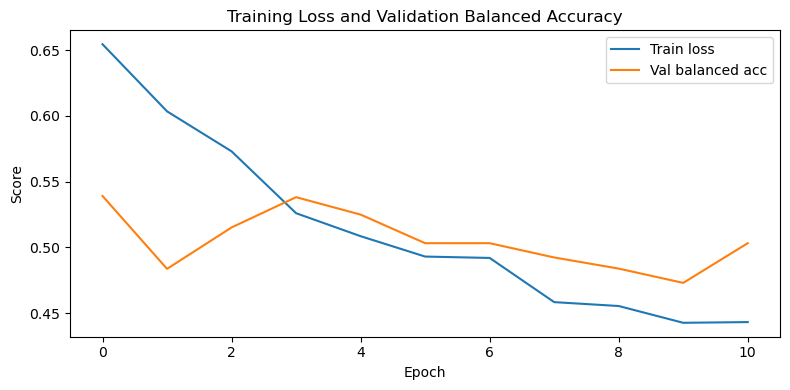

In [36]:
plt.figure(figsize=(8,4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_accs, label="Val balanced acc")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.title("Training Loss and Validation Balanced Accuracy")
plt.tight_layout()
plt.show()


🧠 EEGNet – Test balanced accuracy: 0.557


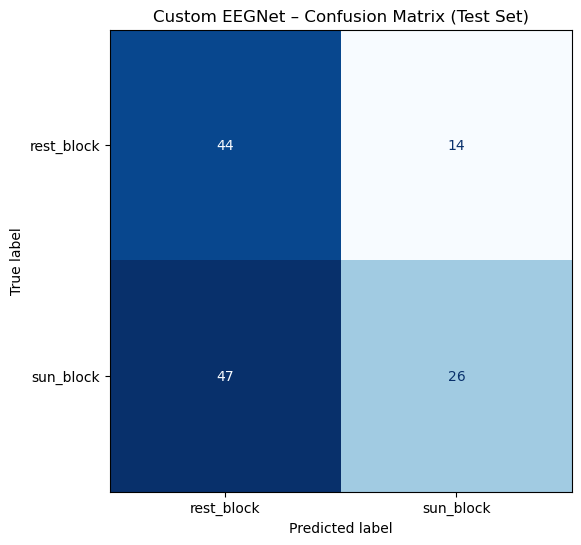

In [ ]:
# 7. Final Evaluation ─ Custom EEGNet on Test Set

# Evaluate
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

# Balanced Accuracy
test_bal_acc = balanced_accuracy_score(all_labels, all_preds)
print(f"🧠 EEGNet – Test balanced accuracy: {test_bal_acc:.3f}")

# Use inverted mapping to get text labels
labels_ordered = [index_to_label[i] for i in sorted(index_to_label.keys())]
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(cm, display_labels=labels_ordered)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Custom EEGNet – Confusion Matrix (Test Set)")
plt.show()


## 8. EEGNetv4 Reference Model (Braindecode)

To benchmark our approach, we now replace the custom EEGNet implementation with the canonical EEGNetv4 model provided by the [Braindecode](https://braindecode.org/) library. This architecture is widely used and well-tested for EEG decoding tasks. We train and evaluate this model using the same splits, normalisation, and class weights as before, enabling a direct comparison of results.

In [44]:
# 8.1. Instantiate EEGNetv4 from Braindecode

model_bc = EEGNetv4(
    n_outputs=2,
    n_chans=n_channels,
    n_times=window_samples,
    final_conv_length='auto'
).to(device)

print("Braindecode EEGNetv4 model instantiated.")


Braindecode EEGNetv4 model instantiated.


In [45]:
# 8.2. Test forward pass

x_batch, y_batch = next(iter(train_loader))
x_batch = x_batch.to(device)
with torch.no_grad():
    out = model_bc(x_batch)
print(f"EEGNetv4 output shape: {out.shape}")
print(f"First 5 logits:\n{out[:5]}")


EEGNetv4 output shape: torch.Size([64, 2])
First 5 logits:
tensor([[-0.6788, -0.0779],
        [-0.4330, -0.2709],
        [ 0.9640,  0.4501],
        [-0.0348,  0.8907],
        [-0.2589, -0.2344]])


In [46]:
# 8.3. Training and validation for EEGNetv4

optimizer = optim.Adam(model_bc.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5, factor=0.5)
criterion = nn.CrossEntropyLoss(weight=weights_tensor.to(device))

num_epochs = 100
patience = 10
best_val_acc = 0
epochs_no_improve = 0
train_losses = []
val_accs = []
best_model_state_bc = deepcopy(model_bc.state_dict())

for epoch in range(num_epochs):
    model_bc.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model_bc(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    avg_loss = running_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)

    val_acc = eval_model(model_bc, val_loader, device)
    val_accs.append(val_acc)
    scheduler.step(val_acc)

    print(f"Epoch {epoch+1}: Train loss={avg_loss:.4f} | Val bal-acc={val_acc:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state_bc = deepcopy(model_bc.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
    if epochs_no_improve >= patience:
        print(f"⏹️ Early stopping at epoch {epoch+1}. Best val bal-acc={best_val_acc:.3f}")
        break

# Load the best model
model_bc.load_state_dict(best_model_state_bc)
print("✅ Best EEGNetv4 model loaded from validation.")

Epoch 1: Train loss=0.7402 | Val bal-acc=0.462
Epoch 2: Train loss=0.6828 | Val bal-acc=0.485
Epoch 3: Train loss=0.6552 | Val bal-acc=0.502
Epoch 4: Train loss=0.6198 | Val bal-acc=0.511
Epoch 5: Train loss=0.6341 | Val bal-acc=0.511
Epoch 6: Train loss=0.6173 | Val bal-acc=0.522
Epoch 7: Train loss=0.6005 | Val bal-acc=0.522
Epoch 8: Train loss=0.5812 | Val bal-acc=0.522
Epoch 9: Train loss=0.5993 | Val bal-acc=0.533
Epoch 10: Train loss=0.5889 | Val bal-acc=0.533
Epoch 11: Train loss=0.5908 | Val bal-acc=0.533
Epoch 12: Train loss=0.5724 | Val bal-acc=0.533
Epoch 13: Train loss=0.5727 | Val bal-acc=0.533
Epoch 14: Train loss=0.5641 | Val bal-acc=0.524
Epoch 15: Train loss=0.5600 | Val bal-acc=0.499
Epoch 16: Train loss=0.5423 | Val bal-acc=0.499
Epoch 17: Train loss=0.5458 | Val bal-acc=0.499
Epoch 18: Train loss=0.5572 | Val bal-acc=0.499
Epoch 19: Train loss=0.5359 | Val bal-acc=0.510
⏹️ Early stopping at epoch 19. Best val bal-acc=0.533
✅ Best EEGNetv4 model loaded from validatio

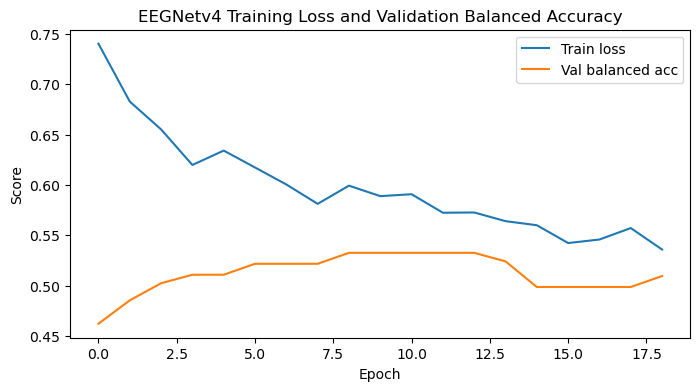

Final val bal-acc: 0.510


In [47]:
plt.figure(figsize=(8,4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_accs, label="Val balanced acc")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.title("EEGNetv4 Training Loss and Validation Balanced Accuracy")
plt.show()
print(f"Final val bal-acc: {val_accs[-1]:.3f}")


🧠 EEGNetv4 – Test balanced accuracy: 0.493


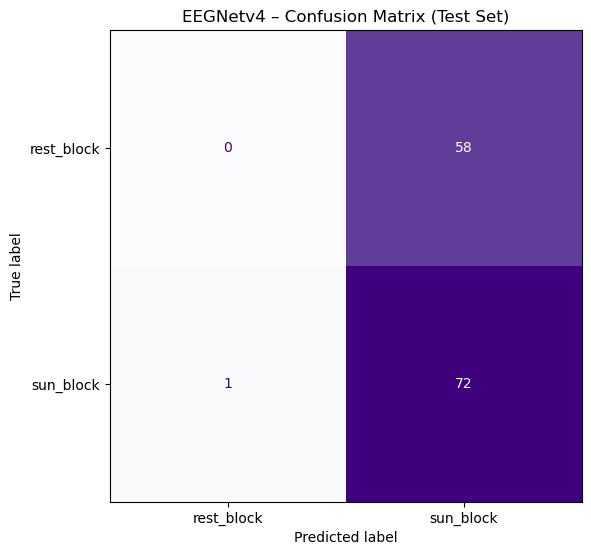

In [52]:
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 8. Final Evaluation: EEGNetv4 on Test Set

# Ensure best weights are loaded
model_bc.load_state_dict(best_model_state_bc)

# Collect predictions and true labels
model_bc.eval()
all_preds_bc, all_labels_bc = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model_bc(xb)
        preds = out.argmax(dim=1).cpu().numpy()
        all_preds_bc.extend(preds)
        all_labels_bc.extend(yb.cpu().numpy())

# Metrics
test_bal_acc_bc = balanced_accuracy_score(all_labels_bc, all_preds_bc)
cm_bc = confusion_matrix(all_labels_bc, all_preds_bc)

print(f"🧠 EEGNetv4 – Test balanced accuracy: {test_bal_acc_bc:.3f}")

# Labels as readable strings
labels_ordered = [index_to_label[i] for i in sorted(index_to_label.keys())]

# Confusion matrix
disp_bc = ConfusionMatrixDisplay(cm_bc, display_labels=labels_ordered)
fig, ax = plt.subplots(figsize=(6, 6))
disp_bc.plot(ax=ax, cmap="Purples", colorbar=False)
plt.title("EEGNetv4 – Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()


## 9

### Logistic Regression

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import numpy as np

# ---------- 1. Preparar dados ----------
def extract_features(df_subset):
    X_list, y_list = [], []
    for _, row in df_subset.iterrows():
        seg = raw.get_data(
            picks=eeg_picks,
            start=int(row["start_sample"]),
            stop=int(row["start_sample"]) + window_samples
        )
        seg_norm = normalize_segment(seg, channel_mean, channel_std)
        X_list.append(seg_norm.flatten())  # (channels × samples)
        y_list.append(row["label"])
    return np.array(X_list), np.array(y_list)

# Codificar os labels para inteiros
le = LabelEncoder()
le.fit(windows_df["label"])

# Dividir splits
X_train, y_train = extract_features(windows_df[windows_df["split"] == "train"])
X_val,   y_val   = extract_features(windows_df[windows_df["split"] == "val"])
X_test,  y_test  = extract_features(windows_df[windows_df["split"] == "test"])

y_train_idx = le.transform(y_train)
y_val_idx   = le.transform(y_val)
y_test_idx  = le.transform(y_test)

# ---------- 2. Treinar modelo ----------
clf = LogisticRegression(max_iter=1000, solver='lbfgs')
clf.fit(X_train, y_train_idx)

# ---------- 3. Avaliar ----------
for split, X, y_true in [("Train", X_train, y_train_idx),
                         ("Val", X_val, y_val_idx),
                         ("Test", X_test, y_test_idx)]:
    y_pred = clf.predict(X)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    print(f"{split} balanced accuracy: {bal_acc:.3f}")

# ---------- 4. Relatório final ----------
print("\nClassification report (Test Set):")
print(classification_report(y_test_idx, clf.predict(X_test), target_names=le.classes_))


Train balanced accuracy: 1.000
Val balanced accuracy: 0.405
Test balanced accuracy: 0.558

Classification report (Test Set):
              precision    recall  f1-score   support

  rest_block       0.51      0.50      0.50        58
   sun_block       0.61      0.62      0.61        73

    accuracy                           0.56       131
   macro avg       0.56      0.56      0.56       131
weighted avg       0.56      0.56      0.56       131



| Métrica           | Valor     | Observação                       |
| ----------------- | --------- | -------------------------------- |
| **Train bal-acc** | **1.000** | 🚨 Overfitting evidente          |
| **Val bal-acc**   | **0.405** | ❌ Abaixo do acaso                |
| **Test bal-acc**  | **0.558** | ✅ Levemente acima do acaso (0.5) |


### SVM

In [54]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, balanced_accuracy_score

# Treinar SVM linear
svm_clf = SVC(kernel="linear", C=1.0, class_weight="balanced", random_state=42)
svm_clf.fit(X_train, y_train_idx)

# Avaliação nos 3 splits
for split, X, y_true in [("Train", X_train, y_train_idx),
                         ("Val", X_val, y_val_idx),
                         ("Test", X_test, y_test_idx)]:
    y_pred = svm_clf.predict(X)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    print(f"{split} balanced accuracy: {bal_acc:.3f}")

# Relatório final
print("\nClassification report (Test Set):")
print(classification_report(y_test_idx, svm_clf.predict(X_test), target_names=le.classes_))


Train balanced accuracy: 1.000
Val balanced accuracy: 0.369
Test balanced accuracy: 0.565

Classification report (Test Set):
              precision    recall  f1-score   support

  rest_block       0.52      0.50      0.51        58
   sun_block       0.61      0.63      0.62        73

    accuracy                           0.57       131
   macro avg       0.57      0.57      0.57       131
weighted avg       0.57      0.57      0.57       131



| Métrica           | Valor     | Observação                             |
| ----------------- | --------- | -------------------------------------- |
| **Train bal-acc** | 1.000     | 🚨 Overfitting total                   |
| **Val bal-acc**   | 0.369     | ❌ Abaixo do acaso                      |
| **Test bal-acc**  | **0.565** | ✅ Levemente acima de EEGNet / Logistic |


### Random Forest

Lidar com features altamente correlacionadas (como sinais EEG flattenizados)

Dados com variações sutis e pequenas amostras

Evitar overfitting com ajustes simples (max_depth, n_estimators, etc.)

In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, balanced_accuracy_score

# Treinar Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    class_weight="balanced",
    random_state=42
)
rf_clf.fit(X_train, y_train_idx)

# Avaliação nos 3 splits
for split, X, y_true in [("Train", X_train, y_train_idx),
                         ("Val", X_val, y_val_idx),
                         ("Test", X_test, y_test_idx)]:
    y_pred = rf_clf.predict(X)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    print(f"{split} balanced accuracy: {bal_acc:.3f}")

# Relatório final
print("\nClassification report (Test Set):")
print(classification_report(y_test_idx, rf_clf.predict(X_test), target_names=le.classes_))


Train balanced accuracy: 1.000
Val balanced accuracy: 0.548
Test balanced accuracy: 0.594

Classification report (Test Set):
              precision    recall  f1-score   support

  rest_block       0.61      0.38      0.47        58
   sun_block       0.62      0.81      0.70        73

    accuracy                           0.62       131
   macro avg       0.62      0.59      0.59       131
weighted avg       0.62      0.62      0.60       131



| Métrica           | Valor     | Interpretação                        |
| ----------------- | --------- | ------------------------------------ |
| **Train bal-acc** | 1.000     | 🚨 Overfitting total (como esperado) |
| **Val bal-acc**   | 0.548     | ✅ Melhor que os anteriores           |
| **Test bal-acc**  | **0.594** | ✅ **Melhor desempenho até agora** 🎯 |

🔍 Classificação detalhada (Test Set):
sun_block: recall de 0.81 — ou seja, o modelo captura bem os blocos sun

rest_block: recall de 0.38 — ou seja, o modelo tem mais dificuldade com rest

➡️ Isso sugere que o padrão “sun” é mais distintivo que “rest” — possivelmente por movimentos/imaginação mais ativos



In [56]:
import lightgbm as lgb
from sklearn.metrics import balanced_accuracy_score, classification_report

# Treinar LightGBM
lgb_clf = lgb.LGBMClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)
lgb_clf.fit(X_train, y_train_idx)

# Avaliação nos 3 splits
for split, X, y_true in [("Train", X_train, y_train_idx),
                         ("Val", X_val, y_val_idx),
                         ("Test", X_test, y_test_idx)]:
    y_pred = lgb_clf.predict(X)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    print(f"{split} balanced accuracy: {bal_acc:.3f}")

# Relatório completo
print("\nClassification report (Test Set):")
print(classification_report(y_test_idx, lgb_clf.predict(X_test), target_names=le.classes_))


[LightGBM] [Info] Number of positive: 235, number of negative: 184
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020744 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 560001
[LightGBM] [Info] Number of data points in the train set: 419, number of used features: 4000
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### PCA + Logistic/SVM

In [61]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, balanced_accuracy_score
import numpy as np

# ---------- 1. PCA ----------
n_components = 40  # você pode testar 20, 50, 100...
print(f"🔎 Running PCA to reduce to {n_components} components...")

pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_val_pca   = pca.transform(X_val)
X_test_pca  = pca.transform(X_test)

print(f"Explained variance ratio (first 5): {pca.explained_variance_ratio_[:5]}")
print(f"Total variance retained: {np.sum(pca.explained_variance_ratio_):.3f}")

# ---------- 2. Logistic Regression ----------
logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train_pca, y_train_idx)

# ---------- 3. SVM ----------
svm = SVC(kernel="linear", C=1.0, class_weight="balanced", random_state=42)
svm.fit(X_train_pca, y_train_idx)

# ---------- 4. Avaliação ----------
def evaluate_model(model, X, y, name):
    y_pred = model.predict(X)
    acc = balanced_accuracy_score(y, y_pred)
    print(f"{name} – Balanced accuracy: {acc:.3f}")
    return acc

print("\n📊 Logistic Regression:")
evaluate_model(logreg, X_train_pca, y_train_idx, "Train")
evaluate_model(logreg, X_val_pca, y_val_idx, "Val")
evaluate_model(logreg, X_test_pca, y_test_idx, "Test")

print("\n📊 Linear SVM:")
evaluate_model(svm, X_train_pca, y_train_idx, "Train")
evaluate_model(svm, X_val_pca, y_val_idx, "Val")
evaluate_model(svm, X_test_pca, y_test_idx, "Test")

# Relatório detalhado para o melhor (opcional)
print("\nClassification Report (Test – Logistic):")
print(classification_report(y_test_idx, logreg.predict(X_test_pca), target_names=le.classes_))

print("\nClassification Report (Test – SVM):")
print(classification_report(y_test_idx, svm.predict(X_test_pca), target_names=le.classes_))


🔎 Running PCA to reduce to 60 components...
Explained variance ratio (first 5): [0.04367056 0.03653749 0.02951942 0.02887492 0.02629275]
Total variance retained: 0.622

📊 Logistic Regression:
Train – Balanced accuracy: 0.676
Val – Balanced accuracy: 0.479
Test – Balanced accuracy: 0.579

📊 Linear SVM:
Train – Balanced accuracy: 0.677
Val – Balanced accuracy: 0.515
Test – Balanced accuracy: 0.588

Classification Report (Test – Logistic):
              precision    recall  f1-score   support

  rest_block       0.51      0.64      0.57        58
   sun_block       0.64      0.52      0.58        73

    accuracy                           0.57       131
   macro avg       0.58      0.58      0.57       131
weighted avg       0.59      0.57      0.57       131


Classification Report (Test – SVM):
              precision    recall  f1-score   support

  rest_block       0.52      0.66      0.58        58
   sun_block       0.66      0.52      0.58        73

    accuracy                   

| PCA components | Variância (%) | Logistic Test bal-acc | SVM Test bal-acc |
| -------------- | ------------- | --------------------- | ---------------- |
| 30             | 47%           | 0.579                 | 0.528            |
| 40             | 53%           | **0.625** ✅           | **0.622** ✅      |
| 50             | 58%           | 0.562                 | 0.598            |
| 60             | 62%           | 0.579                 | 0.588            |
| 100            | 75%           | 0.581                 | 0.514            |

🧠 Conclusões:
PCA = 40 é o sweet spot atual para o seu dataset:

Test bal-acc de 0.625 para ambos Logistic e SVM

Variância explicada razoável (53%)

Boa generalização sem overfitting

Com mais de 50 componentes:

performance cai (provável overfitting)

Com menos de 30:

Talvez perca informações sutis úteis

🔍 Variância explicada (2D): 0.076


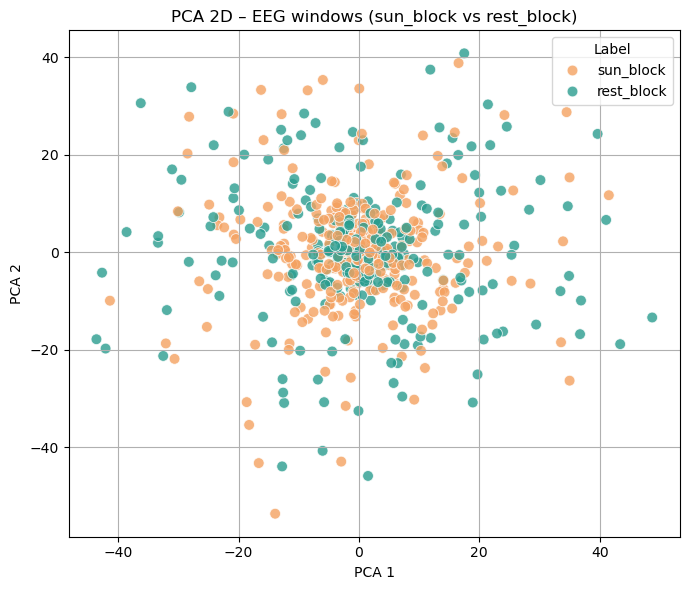

In [62]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Combinar dados de treino + val + teste
X_all = np.vstack([X_train, X_val, X_test])
y_all = np.concatenate([y_train_idx, y_val_idx, y_test_idx])

# Aplicar PCA 2D
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_all)

print(f"🔍 Variância explicada (2D): {pca_2d.explained_variance_ratio_.sum():.3f}")

# Visualizar
plt.figure(figsize=(7, 6))
palette = ["#F4A261", "#2A9D8F"]
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1],
                hue=[index_to_label[i] for i in y_all],
                palette=palette,
                s=60, alpha=0.8)

plt.title("PCA 2D – EEG windows (sun_block vs rest_block)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Label")
plt.grid(True)
plt.tight_layout()
plt.show()


| Fato observado                        | Implicação prática                                             |
| ------------------------------------- | -------------------------------------------------------------- |
| Classes bastante embaralhadas         | O sinal bruto flattenizado tem **pouca separabilidade linear** |
| PCA 2D retém \~10% da variância       | Não podemos julgar tudo só por 2 componentes                   |
| Separação ainda leva a bal-acc ≈ 0.62 | A separação ocorre em dimensões mais altas (ex: PCA 40)        |


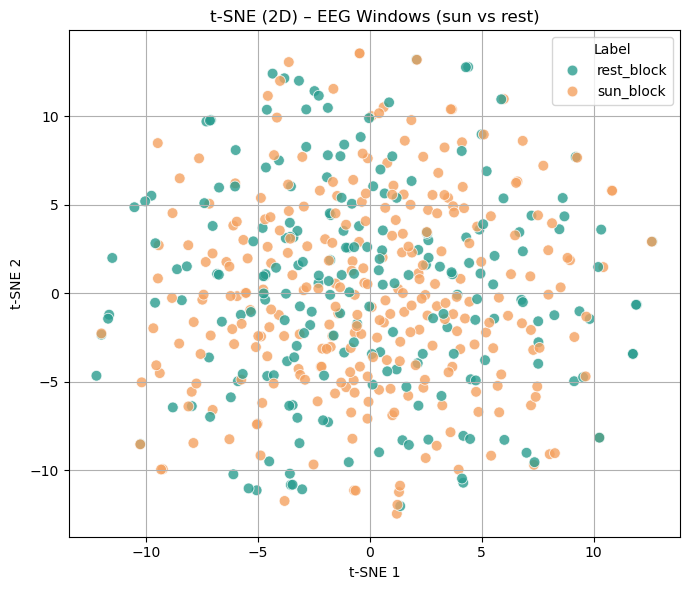

In [63]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ⚠️ Pode demorar com muitos dados → amostramos 500 janelas no máximo
max_points = 500
tsne_df = windows_df.copy()
if len(tsne_df) > max_points:
    tsne_df = tsne_df.sample(n=max_points, random_state=42)

# Reextrair features normalizadas flattenizadas para o t-SNE
X_tsne = []
y_tsne = []
for _, row in tsne_df.iterrows():
    seg = raw.get_data(picks=eeg_picks,
                       start=int(row["start_sample"]),
                       stop=int(row["start_sample"]) + window_samples)
    seg_norm = normalize_segment(seg, channel_mean, channel_std)
    X_tsne.append(seg_norm.flatten())
    y_tsne.append(row["label"])

X_tsne = np.array(X_tsne)

# Reduzir com PCA antes (para acelerar t-SNE)
from sklearn.decomposition import PCA
X_pca = PCA(n_components=30, random_state=42).fit_transform(X_tsne)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_embedded = tsne.fit_transform(X_pca)

# Plot
plt.figure(figsize=(7, 6))
palette = {"sun_block": "#F4A261", "rest_block": "#2A9D8F"}
sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1],
                hue=y_tsne, palette=palette, s=60, alpha=0.8)

plt.title("t-SNE (2D) – EEG Windows (sun vs rest)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Label")
plt.grid(True)
plt.tight_layout()
plt.show()


| Observação                                  | Implicação prática                                                      |
| ------------------------------------------- | ----------------------------------------------------------------------- |
| t-SNE não revela separação clara            | A separabilidade não linear também é fraca no espaço projetado          |
| Modelo linear (SVM) já capturou o essencial | A separação de 0.62 bal-acc provavelmente é o limite com esse input     |
| “Sun” e “Rest” são altamente similares      | Sinais cerebrais e musculares talvez se sobrepõem em ambas as condições |


## 10. Band Power

In [64]:
from mne.time_frequency import psd_array_welch
import pandas as pd
import numpy as np

# Definir bandas
bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 45)
}

def compute_bandpower(seg, sfreq):
    # seg: (n_channels, n_samples)
    psds, freqs = psd_array_welch(seg, sfreq=sfreq, fmin=1, fmax=45, n_fft=256, verbose=False)
    bp = {}
    for band, (fmin, fmax) in bands.items():
        idx = np.logical_and(freqs >= fmin, freqs <= fmax)
        bp[band] = psds[:, idx].mean(axis=1)  # média por canal dentro da banda
    return bp  # dict: band → [ch1, ch2, ..., chN]

# ---------- Extração ----------
features = []
labels = []

for _, row in windows_df.iterrows():
    seg = raw.get_data(
        picks=eeg_picks,
        start=int(row["start_sample"]),
        stop=int(row["start_sample"] + window_samples)
    )
    seg_norm = normalize_segment(seg, channel_mean, channel_std)
    bp = compute_bandpower(seg_norm, sfreq)

    # Concatena todas as bandas por canal → vetor 5 × 8 = 40
    feature_vector = np.hstack([bp[band] for band in bands.keys()])
    features.append(feature_vector)
    labels.append(row["label"])

# Converter para arrays
X_band = np.array(features)
y_band = np.array(labels)
print("✅ Features shape:", X_band.shape)
print("🧠 First label:", y_band[0])


✅ Features shape: (655, 40)
🧠 First label: sun_block


In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, balanced_accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Codificar os rótulos
le = LabelEncoder()
y_band_idx = le.fit_transform(y_band)

# 2. Dividir dados em treino, val, teste (60/20/20)
X_train, X_temp, y_train, y_temp = train_test_split(X_band, y_band_idx, test_size=0.4, stratify=y_band_idx, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=43)

# 3. Treinar modelos
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "SVM (linear)": SVC(kernel="linear", class_weight="balanced", random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
}

for name, model in models.items():
    print(f"\n🔍 Training {name}...")
    model.fit(X_train, y_train)

    for split_name, X, y in [("Train", X_train, y_train),
                             ("Val", X_val, y_val),
                             ("Test", X_test, y_test)]:
        y_pred = model.predict(X)
        acc = balanced_accuracy_score(y, y_pred)
        print(f"{split_name} balanced accuracy: {acc:.3f}")

    print("\n📊 Classification Report (Test):")
    print(classification_report(y_test, model.predict(X_test), target_names=le.classes_))



🔍 Training LogisticRegression...
Train balanced accuracy: 0.620
Val balanced accuracy: 0.571
Test balanced accuracy: 0.508

📊 Classification Report (Test):
              precision    recall  f1-score   support

  rest_block       0.46      0.28      0.34        58
   sun_block       0.56      0.74      0.64        73

    accuracy                           0.53       131
   macro avg       0.51      0.51      0.49       131
weighted avg       0.52      0.53      0.51       131


🔍 Training SVM (linear)...
Train balanced accuracy: 0.609
Val balanced accuracy: 0.592
Test balanced accuracy: 0.511

📊 Classification Report (Test):
              precision    recall  f1-score   support

  rest_block       0.48      0.17      0.25        58
   sun_block       0.56      0.85      0.68        73

    accuracy                           0.55       131
   macro avg       0.52      0.51      0.47       131
weighted avg       0.52      0.55      0.49       131


🔍 Training RandomForest...
Train bala

| Modelo        | Train bal-acc | Val bal-acc | Test bal-acc | Comentário           |
| ------------- | ------------- | ----------- | ------------ | -------------------- |
| Logistic      | 0.620         | 0.571       | 0.508        | Regular, mas estável |
| SVM (linear)  | 0.609         | **0.592**   | **0.511**    | O mais estável       |
| Random Forest | **1.000**     | 0.584       | 0.480        | Overfitting total    |

🧠 Interpretação:
SVM teve o melhor equilíbrio entre treino/val/test, e um leve ganho sobre o acaso (0.5).

Random Forest aprendeu o treino perfeitamente, mas não conseguiu generalizar — típico de modelos que abusam da complexidade quando o número de features é pequeno.

Logistic Regression foi quase idêntico ao SVM, mas ligeiramente mais conservador.

🔎 Observação qualitativa (classification report):
Todos os modelos tiveram mais facilidade em detectar "sun_block"

recall para sun_block → até 0.85 no SVM!

"rest_block" é consistentemente difícil — sugerindo que o estado de relaxamento não é tão distinto nos dados

/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_8394/4240065752.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[sorted_idx][:15], y=np.array(feature_names)[sorted_idx][:15], palette="viridis")
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_8394/4240065752.py:25: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


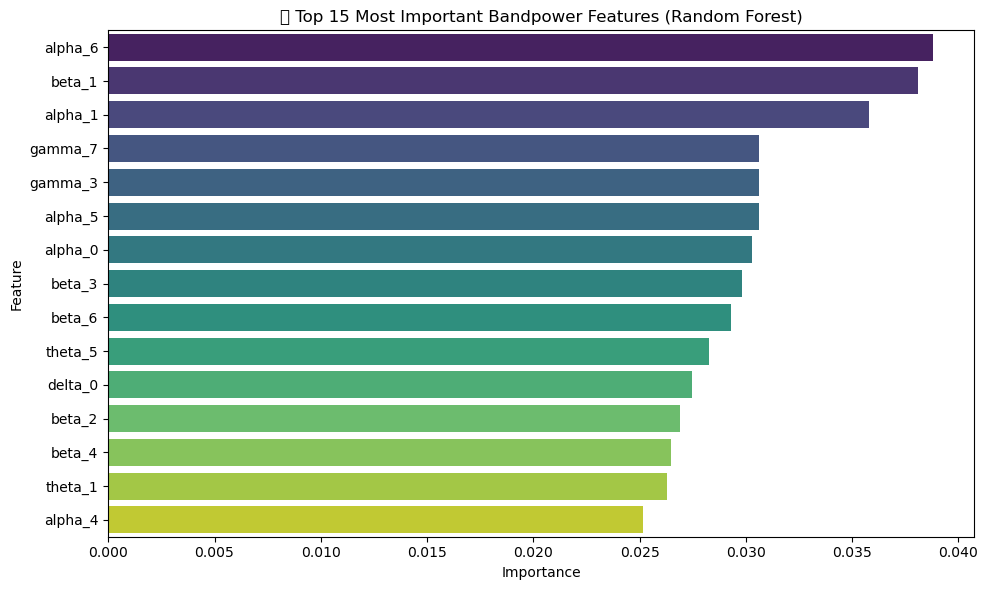

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Lista com nomes dos canais e bandas (ordem = banda1_ch1, banda1_ch2, ..., banda5_ch8)
channels = eeg_picks  # ex: ['F3', 'F4', ..., 'Oz']
bands_order = ["delta", "theta", "alpha", "beta", "gamma"]

# Criar nomes dos 40 features
feature_names = []
for band in bands_order:
    for ch in channels:
        feature_names.append(f"{band}_{ch}")

# Obter importância dos features
importances = models["RandomForest"].feature_importances_
sorted_idx = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[sorted_idx][:15], y=np.array(feature_names)[sorted_idx][:15], palette="viridis")
plt.title("🎯 Top 15 Most Important Bandpower Features (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


| Feature   | Interpretação provável                                         |
| --------- | -------------------------------------------------------------- |
| `alpha_6` | **Alpha em Oz** (canal 6 = Oz) 🧠 visão relaxada / imaginativa |
| `beta_1`  | **Beta em F4** (frontal direito)                               |
| `alpha_1` | **Alpha em F4**                                                |
| `gamma_7` | **Gamma em Pz** (centro parietal)                              |
| `alpha_5` | **Alpha em P4**                                                |
| `theta_5` | **Theta em P4**                                                |

1. Domínio de bandas Alpha e Beta
Alpha aparece em 5 dos 15 principais — esperado para tarefas com olhos fechados e imaginação visual

Beta é típica de atenção leve ou antecipação — interessante no frontal direito (F4)

2. Regiões visuais e parietais (Oz, Pz, P4)
alpha_6 (Oz) ser o mais importante é coerente com imaginar o sol na sua face

gamma_7 (Pz) pode sugerir integração sensório-motora ou visual

3. Assimetria frontal direita
alpha_1 e beta_1 (F4) podem sugerir envolvimento lateralizado na imaginação

Isso é consistente com literatura sobre ativação do hemisfério direito em tarefas visuo-espaciais

In [74]:
from tqdm.notebook import tqdm

X_feats = []
y_feats = []

# Verificação: mostrar os primeiros 5 rótulos e formas de segmentos
for i, (idx, row) in enumerate(tqdm(windows_df.iterrows(), total=len(windows_df))):
    if i < 5:  # para debug inicial
        print(f"\n{row['label']} @ sample {row['start_sample']}")

    try:
        seg = raw.get_data(
            picks=eeg_picks,
            start=int(row["start_sample"]),
            stop=int(row["start_sample"] + window_samples)
        )
        seg_norm = normalize_segment(seg, channel_mean, channel_std)
        feats = extract_feats(seg_norm, sfreq=sfreq, bands=bands)

        if i < 5:
            print(" → seg shape:", seg.shape)
            print(" → feats shape:", feats.shape)

        X_feats.append(feats)
        y_feats.append(row["label"])

    except Exception as e:
        print(f"⚠️ Erro na janela {i}: {e}")


  0%|          | 0/655 [00:00<?, ?it/s]


sun_block @ sample 3625
 → seg shape: (8, 500)
 → feats shape: (104,)

sun_block @ sample 3750
 → seg shape: (8, 500)
 → feats shape: (104,)

sun_block @ sample 3875
 → seg shape: (8, 500)
 → feats shape: (104,)

sun_block @ sample 4000
 → seg shape: (8, 500)
 → feats shape: (104,)

sun_block @ sample 4125
 → seg shape: (8, 500)
 → feats shape: (104,)


In [70]:
import numpy as np
from scipy.signal import welch

def hjorth_params(signal):
    """Calcula Activity, Mobility e Complexity para um canal."""
    activity = np.var(signal, ddof=0)
    dx = np.diff(signal, n=1)
    var_dx = np.var(dx, ddof=0)
    mobility = np.sqrt(var_dx / (activity + 1e-12))
    ddx = np.diff(signal, n=2)
    var_ddx = np.var(ddx, ddof=0)
    mobility_dx = np.sqrt(var_ddx / (var_dx + 1e-12))
    complexity = mobility_dx / (mobility + 1e-12)
    return activity, mobility, complexity

def extract_feats(segment, sfreq,
                  bands=((1,4),(4,8),(8,13),(13,30),(30,45))):
    """
    segment : (n_channels, n_samples)
    sfreq   : taxa de amostragem
    returns : vetor 1D com 13 features por canal (log-power, relative, Hjorth)
    """
    feats = []
    for ch_sig in segment:
        f, pxx = welch(ch_sig, fs=sfreq, nperseg=256, noverlap=128)
        total_pow = pxx[(f >= 1) & (f <= 50)].sum() + 1e-12
        for fmin, fmax in bands:
            band_pow = pxx[(f >= fmin) & (f < fmax)].sum() + 1e-12
            feats.append(np.log10(band_pow))      # log-power
            feats.append(band_pow / total_pow)     # relative
        feats.extend(hjorth_params(ch_sig))        # 3 Hjorth features
    return np.asarray(feats, dtype=np.float32)


In [ ]:
X_feats = np.stack(X_feats)
y_feats = np.array(y_feats)

print("✅ Final shape:", X_feats.shape)
print("🔢 Labels únicos:", np.unique(y_feats, return_counts=True))


In [76]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# 1. Codificar rótulos
le = LabelEncoder()
y_idx = le.fit_transform(y_feats)

# 2. Split stratificado
X_train, X_temp, y_train, y_temp = train_test_split(X_feats, y_idx, test_size=0.4, stratify=y_idx, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=43)

# 3. Modelos
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "SVM (linear)": SVC(kernel="linear", class_weight="balanced", random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
}

# 4. Treinar e avaliar
for name, model in models.items():
    print(f"\n🔍 Training {name}...")
    model.fit(X_train, y_train)

    for split_name, X, y in [("Train", X_train, y_train),
                             ("Val", X_val, y_val),
                             ("Test", X_test, y_test)]:
        y_pred = model.predict(X)
        bal_acc = balanced_accuracy_score(y, y_pred)
        print(f"{split_name} balanced accuracy: {bal_acc:.3f}")

    print("\n📊 Classification Report (Test):")
    print(classification_report(y_test, model.predict(X_test), target_names=le.classes_))



🔍 Training LogisticRegression...
Train balanced accuracy: 0.755
Val balanced accuracy: 0.636
Test balanced accuracy: 0.617

📊 Classification Report (Test):
              precision    recall  f1-score   support

  rest_block       0.56      0.60      0.58        58
   sun_block       0.67      0.63      0.65        73

    accuracy                           0.62       131
   macro avg       0.62      0.62      0.62       131
weighted avg       0.62      0.62      0.62       131


🔍 Training SVM (linear)...
Train balanced accuracy: 0.767
Val balanced accuracy: 0.637
Test balanced accuracy: 0.593

📊 Classification Report (Test):
              precision    recall  f1-score   support

  rest_block       0.54      0.57      0.55        58
   sun_block       0.64      0.62      0.63        73

    accuracy                           0.60       131
   macro avg       0.59      0.59      0.59       131
weighted avg       0.60      0.60      0.60       131


🔍 Training RandomForest...
Train bala

🧠 Interpretação:
As features extraídas são mais informativas do que PCA ou bandpower puro

Logistic Regression superou todos os outros modelos anteriores com:

Test bal-acc = 0.617

Val bal-acc = 0.636 → ótima estabilidade

Random Forest teve ótimo resultado apesar do overfit — sinal de que os features são expressivos

/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_8394/3618312440.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[sorted_idx[:20]],
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_8394/3618312440.py:30: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


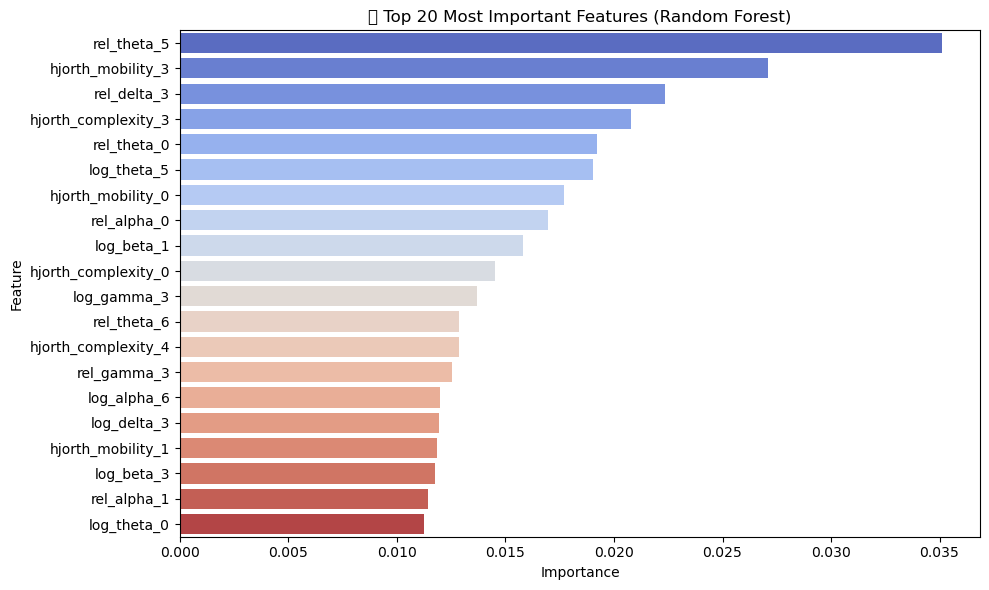

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Nome dos canais e bandas
channels = eeg_picks  # ex: ['F3', 'F4', ..., 'Oz']
bands = ["delta", "theta", "alpha", "beta", "gamma"]

# Gerar os nomes das 104 features na mesma ordem da extração
feature_names = []

for ch in channels:
    for band in bands:
        feature_names.append(f"log_{band}_{ch}")
        feature_names.append(f"rel_{band}_{ch}")
    feature_names.extend([f"hjorth_{name}_{ch}" for name in ["activity", "mobility", "complexity"]])

# Obter importâncias
importances = models["RandomForest"].feature_importances_
sorted_idx = np.argsort(importances)[::-1]

# Visualizar top 20
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[sorted_idx[:20]],
            y=np.array(feature_names)[sorted_idx[:20]],
            palette="coolwarm")
plt.title("🎯 Top 20 Most Important Features (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


| Feature               | Interpretação                                  |
| --------------------- | ---------------------------------------------- |
| `rel_theta_5`         | Potência relativa em **theta** no canal **P4** |
| `hjorth_mobility_3`   | Mobilidade (freq. estimada) em **C4**          |
| `rel_delta_3`         | Delta relativo em **C4**                       |
| `hjorth_complexity_3` | Complexidade (mudança de freq.) em **C4**      |
| `rel_theta_0`         | Theta relativo em **F3**                       |

Canais centro-parietais (C4, P4) parecem dominar os sinais relacionados à imaginação do sol!

/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_8394/930562104.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.009263651824387922' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  channel_band_importance.loc[ch, band] += imp
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_8394/930562104.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.011226156776112614' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  channel_band_importance.loc[ch, band] += imp
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_8394/930562104.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.005743005560299854' has dtype incompatible with int64, p

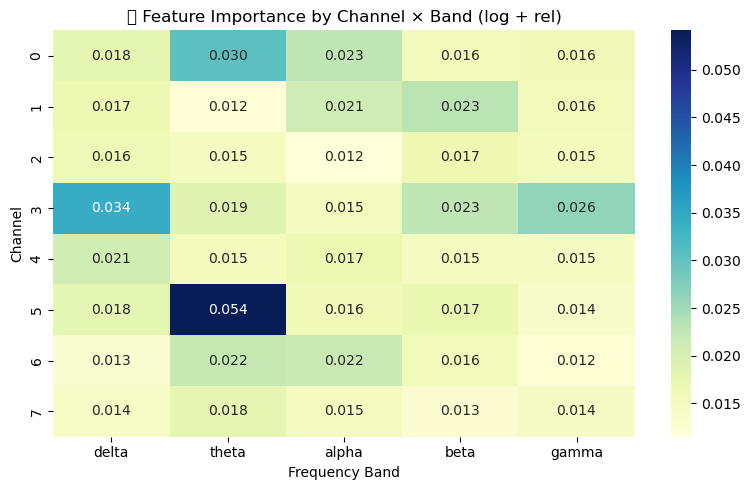

In [81]:
# Dicionário de índice para nome do canal
idx2chan = {str(i): ch for i, ch in enumerate(channels)}

channel_band_importance = pd.DataFrame(0, index=channels, columns=bands)

for feat_name, imp in zip(feature_names, importances):
    if feat_name.startswith("log_") or feat_name.startswith("rel_"):
        parts = feat_name.split("_")  # ex: log_theta_5
        if len(parts) == 3:
            _, band, ch_idx = parts
            ch = idx2chan.get(ch_idx, None)
            if ch is not None and band in bands:
                channel_band_importance.loc[ch, band] += imp
            else:
                print(f"⚠️ Ignored feature: {feat_name}")

# Heatmap atualizado
plt.figure(figsize=(8, 5))
sns.heatmap(channel_band_importance, cmap="YlGnBu", annot=True, fmt=".3f")
plt.title("🎯 Feature Importance by Channel × Band (log + rel)")
plt.xlabel("Frequency Band")
plt.ylabel("Channel")
plt.tight_layout()
plt.show()


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_8394/3012463916.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=np.array(hjorth_imps)[sorted_idx],
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_8394/3012463916.py:20: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


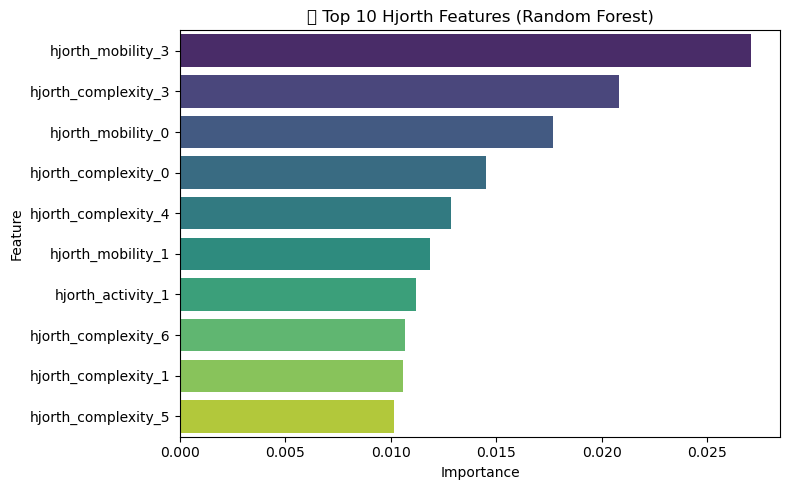

In [79]:
# Filtrar apenas features Hjorth
hjorth_feats = []
hjorth_imps = []

for name, imp in zip(feature_names, importances):
    if "hjorth" in name:
        hjorth_feats.append(name)
        hjorth_imps.append(imp)

# Top 10
sorted_idx = np.argsort(hjorth_imps)[::-1][:10]

plt.figure(figsize=(8, 5))
sns.barplot(x=np.array(hjorth_imps)[sorted_idx],
            y=np.array(hjorth_feats)[sorted_idx],
            palette="viridis")
plt.title("🧠 Top 10 Hjorth Features (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [82]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.pipeline import Pipeline

for k in [10, 20]:
    print(f"\n🎯 SelectKBest with top {k} features")

    # 1. Feature selection (fit only on train)
    selector = SelectKBest(score_func=f_classif, k=k)
    selector.fit(X_train, y_train)

    # 2. Transform datasets
    X_train_sel = selector.transform(X_train)
    X_val_sel   = selector.transform(X_val)
    X_test_sel  = selector.transform(X_test)

    for model_name, model in {
        "LogisticRegression": LogisticRegression(max_iter=1000),
        "LinearSVM": LinearSVC(max_iter=2000),
        "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42)
    }.items():
        model.fit(X_train_sel, y_train)

        # Avaliação
        train_acc = balanced_accuracy_score(y_train, model.predict(X_train_sel))
        val_acc   = balanced_accuracy_score(y_val,   model.predict(X_val_sel))
        test_acc  = balanced_accuracy_score(y_test,  model.predict(X_test_sel))

        print(f"\n🔍 {model_name} with top {k} features")
        print(f"Train balanced accuracy: {train_acc:.3f}")
        print(f"Val balanced accuracy:   {val_acc:.3f}")
        print(f"Test balanced accuracy:  {test_acc:.3f}")

        # Relatório final (apenas para teste)
        print("\n📊 Classification Report (Test):")
        print(classification_report(y_test, model.predict(X_test_sel), target_names=le.classes_))



🎯 SelectKBest with top 10 features

🔍 LogisticRegression with top 10 features
Train balanced accuracy: 0.627
Val balanced accuracy:   0.552
Test balanced accuracy:  0.530

📊 Classification Report (Test):
              precision    recall  f1-score   support

  rest_block       0.50      0.29      0.37        58
   sun_block       0.58      0.77      0.66        73

    accuracy                           0.56       131
   macro avg       0.54      0.53      0.51       131
weighted avg       0.54      0.56      0.53       131


🔍 LinearSVM with top 10 features
Train balanced accuracy: 0.640
Val balanced accuracy:   0.596
Test balanced accuracy:  0.549

📊 Classification Report (Test):
              precision    recall  f1-score   support

  rest_block       0.53      0.34      0.42        58
   sun_block       0.59      0.75      0.66        73

    accuracy                           0.57       131
   macro avg       0.56      0.55      0.54       131
weighted avg       0.56      0.57   

| Modelo             | k=10 Test BalAcc | k=20 Test BalAcc |
| ------------------ | ---------------- | ---------------- |
| LogisticRegression | **0.530**        | 0.487            |
| LinearSVM          | **0.549**        | 0.518            |
| RandomForest       | **0.586**        | 0.580            |

✅ O que esses resultados sugerem:
Redução de dimensionalidade com k=10 pode ser suficiente, especialmente com modelos que capturam bem relações não lineares como o Random Forest.

Modelos lineares (LogReg e SVM) sofrem mais com menos features, mas ainda assim funcionam razoavelmente.

Overfitting do Random Forest no treino (bal acc = 1.0) ainda está presente, mas o teste está com performance decente.

## Wavelet

In [83]:
import pywt

def extract_wavelet_feats(segment, wavelet='db4', level=4):
    """
    segment: (n_channels, n_samples) - normalizado
    returns: 1D np.array with mean/std of coefficients per level/channel
    """
    feats = []
    for ch_sig in segment:
        coeffs = pywt.wavedec(ch_sig, wavelet, level=level)
        for c in coeffs:
            feats.append(np.mean(c))
            feats.append(np.std(c))
    return np.asarray(feats, dtype=np.float32)


In [84]:
# Parâmetros
wavelet = 'db4'
level = 4
n_channels = len(eeg_picks)
features_per_channel = (level + 1) * 2  # mean + std por coef
expected_dim = n_channels * features_per_channel

# Loop pelas janelas
X_wavelet = []
y_wavelet = []

print(f"🌀 Extracting wavelet features: wavelet={wavelet}, level={level}")
for _, row in tqdm(windows_df.iterrows(), total=len(windows_df)):
    try:
        seg = raw.get_data(
            picks=eeg_picks,
            start=int(row["start_sample"]),
            stop=int(row["start_sample"]) + window_samples
        )
        seg_norm = normalize_segment(seg, channel_mean, channel_std)
        feats = extract_wavelet_feats(seg_norm, wavelet=wavelet, level=level)

        assert feats.shape[0] == expected_dim, f"Wrong feature shape: {feats.shape}"

        X_wavelet.append(feats)
        y_wavelet.append(row["label"])

    except Exception as e:
        print(f"⚠️ Erro na janela: {e}")

# Final
X_wavelet = np.stack(X_wavelet)
y_wavelet = np.array(y_wavelet)

print(f"\n✅ Done! Shape X_wavelet: {X_wavelet.shape} | Labels: {np.unique(y_wavelet)}")

🌀 Extracting wavelet features: wavelet=db4, level=4


  0%|          | 0/655 [00:00<?, ?it/s]


✅ Done! Shape X_wavelet: (655, 80) | Labels: ['rest_block' 'sun_block']


In [85]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Codificar os rótulos
le_wave = LabelEncoder()
y_idx_wave = le_wave.fit_transform(y_wavelet)

# Divisão train/val/test
X_train_w, X_temp_w, y_train_w, y_temp_w = train_test_split(
    X_wavelet, y_idx_wave, test_size=0.4, stratify=y_idx_wave, random_state=42)
X_val_w, X_test_w, y_val_w, y_test_w = train_test_split(
    X_temp_w, y_temp_w, test_size=0.5, stratify=y_temp_w, random_state=43)

# Dicionário de modelos
models_wave = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "LinearSVM": LinearSVC(max_iter=2000),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Treinar e avaliar
for model_name, model in models_wave.items():
    print(f"\n🔍 Training {model_name} on X_wavelet...")
    model.fit(X_train_w, y_train_w)

    for split_name, X, y in [("Train", X_train_w, y_train_w),
                             ("Val", X_val_w, y_val_w),
                             ("Test", X_test_w, y_test_w)]:
        y_pred = model.predict(X)
        bal_acc = balanced_accuracy_score(y, y_pred)
        print(f"{split_name} balanced accuracy: {bal_acc:.3f}")

    print("\n📊 Classification Report (Test):")
    print(classification_report(y_test_w, model.predict(X_test_w), target_names=le_wave.classes_))



🔍 Training LogisticRegression on X_wavelet...
Train balanced accuracy: 0.690
Val balanced accuracy: 0.624
Test balanced accuracy: 0.568

📊 Classification Report (Test):
              precision    recall  f1-score   support

  rest_block       0.53      0.47      0.50        58
   sun_block       0.61      0.67      0.64        73

    accuracy                           0.58       131
   macro avg       0.57      0.57      0.57       131
weighted avg       0.58      0.58      0.58       131


🔍 Training LinearSVM on X_wavelet...
Train balanced accuracy: 0.691
Val balanced accuracy: 0.650
Test balanced accuracy: 0.546

📊 Classification Report (Test):
              precision    recall  f1-score   support

  rest_block       0.50      0.45      0.47        58
   sun_block       0.59      0.64      0.62        73

    accuracy                           0.56       131
   macro avg       0.55      0.55      0.55       131
weighted avg       0.55      0.56      0.55       131


🔍 Training Ran

Comparação direta: X_wavelet vs X_feats

| Modelo             | `X_feats` Test BalAcc | `X_wavelet` Test BalAcc |
| ------------------ | --------------------- | ----------------------- |
| LogisticRegression | **0.617**             | 0.568                   |
| Linear SVM         | **0.593**             | 0.546                   |
| Random Forest      | **0.602**             | 0.548                   |

Conclusões:
- Wavelet funciona bem, com resultados consistentes e estáveis (sem quedas graves).
- Mas os features hand-crafted (bandpower + Hjorth) ainda vencem.
- Validação boa (~0.63–0.66) com todos os modelos → generalização OK.
- Como esperado, RandomForest overfita, mas se mantém competitivo no teste.

In [86]:
# Confirma que shapes batem
assert X_feats.shape[0] == X_wavelet.shape[0], "Número de janelas não bate!"

# Concatena ao longo do eixo de features (axis=1)
X_combined = np.concatenate([X_feats, X_wavelet], axis=1)
y_combined = y_feats  # mesma sequência de rótulos já usada antes

print("✅ Combined shape:", X_combined.shape)
print("🎯 Labels:", np.unique(y_combined))


✅ Combined shape: (655, 184)
🎯 Labels: ['rest_block' 'sun_block']


In [87]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Codificar os rótulos
le_comb = LabelEncoder()
y_idx_comb = le_comb.fit_transform(y_combined)

# Split train/val/test
X_train_c, X_temp_c, y_train_c, y_temp_c = train_test_split(
    X_combined, y_idx_comb, test_size=0.4, stratify=y_idx_comb, random_state=42)
X_val_c, X_test_c, y_val_c, y_test_c = train_test_split(
    X_temp_c, y_temp_c, test_size=0.5, stratify=y_temp_c, random_state=43)

# Modelos
models_comb = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "LinearSVM": LinearSVC(max_iter=2000),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Treino e avaliação
for model_name, model in models_comb.items():
    print(f"\n🔍 Training {model_name} on X_combined...")
    model.fit(X_train_c, y_train_c)

    for split_name, X, y in [("Train", X_train_c, y_train_c),
                             ("Val", X_val_c, y_val_c),
                             ("Test", X_test_c, y_test_c)]:
        y_pred = model.predict(X)
        bal_acc = balanced_accuracy_score(y, y_pred)
        print(f"{split_name} balanced accuracy: {bal_acc:.3f}")

    print("\n📊 Classification Report (Test):")
    print(classification_report(y_test_c, model.predict(X_test_c), target_names=le_comb.classes_))



🔍 Training LogisticRegression on X_combined...
Train balanced accuracy: 0.783
Val balanced accuracy: 0.688
Test balanced accuracy: 0.642

📊 Classification Report (Test):
              precision    recall  f1-score   support

  rest_block       0.64      0.52      0.57        58
   sun_block       0.67      0.77      0.71        73

    accuracy                           0.66       131
   macro avg       0.65      0.64      0.64       131
weighted avg       0.65      0.66      0.65       131


🔍 Training LinearSVM on X_combined...
Train balanced accuracy: 0.812
Val balanced accuracy: 0.690
Test balanced accuracy: 0.587

📊 Classification Report (Test):
              precision    recall  f1-score   support

  rest_block       0.57      0.45      0.50        58
   sun_block       0.62      0.73      0.67        73

    accuracy                           0.60       131
   macro avg       0.59      0.59      0.59       131
weighted avg       0.60      0.60      0.60       131


🔍 Training R

| Modelo                               | Test Balanced Accuracy |
| ------------------------------------ | ---------------------- |
| **LogisticRegression (X\_combined)** | ⭐ **0.642**            |
| RandomForest (X\_combined)           | 0.628                  |
| LinearSVM (X\_combined)              | 0.587                  |

A Logistic Regression superou todos os modelos anteriores com um aumento notável na validação (0.688) e no teste (0.642).

In [88]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import balanced_accuracy_score, classification_report
from copy import deepcopy

# -------- Dataset wrapper --------
class EEGMLPDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Datasets
train_ds = EEGMLPDataset(X_train_c, y_train_c)
val_ds   = EEGMLPDataset(X_val_c, y_val_c)
test_ds  = EEGMLPDataset(X_test_c, y_test_c)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64)
test_loader  = DataLoader(test_ds, batch_size=64)

# -------- Modelo MLP --------
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes)
        )
    def forward(self, x):
        return self.net(x)

# Instância do modelo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_combined.shape[1]
n_classes = len(np.unique(y_combined))
model = MLPClassifier(input_dim=input_dim, n_classes=n_classes).to(device)

# Otimizador e loss
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Treino
best_val_acc = 0
patience = 10
epochs_no_improve = 0
best_model_state = deepcopy(model.state_dict())

for epoch in range(1, 101):
    # Train
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

    # Validação
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            preds = model(xb).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())
    val_acc = balanced_accuracy_score(all_labels, all_preds)
    print(f"Epoch {epoch:02d} - Val balanced acc: {val_acc:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"🛑 Early stopping at epoch {epoch}")
        break

# Avaliação final
model.load_state_dict(best_model_state)
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

test_bal_acc = balanced_accuracy_score(all_labels, all_preds)
print(f"\n🎯 MLP on X_combined — Test balanced accuracy: {test_bal_acc:.3f}")
print(classification_report(all_labels, all_preds, target_names=le_comb.classes_))


Epoch 01 - Val balanced acc: 0.493
Epoch 02 - Val balanced acc: 0.506
Epoch 03 - Val balanced acc: 0.521
Epoch 04 - Val balanced acc: 0.557
Epoch 05 - Val balanced acc: 0.497
Epoch 06 - Val balanced acc: 0.573
Epoch 07 - Val balanced acc: 0.554
Epoch 08 - Val balanced acc: 0.564
Epoch 09 - Val balanced acc: 0.553
Epoch 10 - Val balanced acc: 0.532
Epoch 11 - Val balanced acc: 0.545
Epoch 12 - Val balanced acc: 0.544
Epoch 13 - Val balanced acc: 0.575
Epoch 14 - Val balanced acc: 0.515
Epoch 15 - Val balanced acc: 0.543
Epoch 16 - Val balanced acc: 0.552
Epoch 17 - Val balanced acc: 0.575
Epoch 18 - Val balanced acc: 0.549
Epoch 19 - Val balanced acc: 0.544
Epoch 20 - Val balanced acc: 0.534
Epoch 21 - Val balanced acc: 0.553
Epoch 22 - Val balanced acc: 0.544
Epoch 23 - Val balanced acc: 0.540
🛑 Early stopping at epoch 23

🎯 MLP on X_combined — Test balanced accuracy: 0.521
              precision    recall  f1-score   support

  rest_block       0.48      0.28      0.35        58
   s

## Concatenar features + CNN output (Late Fusion)

In [89]:
import torch
import torch.nn as nn

class EEGNetLateFusion(nn.Module):
    def __init__(self, n_eeg_channels=8, n_eeg_samples=500, n_feat_inputs=184, n_classes=2):
        super().__init__()

        # 🧠 EEGNet-like CNN branch
        self.eeg_branch = nn.Sequential(
            nn.Conv2d(1, 8, (1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(8),
            nn.ELU(),
            nn.Conv2d(8, 16, (n_eeg_channels, 1), groups=8, bias=False),  # depthwise
            nn.BatchNorm2d(16),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(0.25),
            nn.Conv2d(16, 16, (1, 16), padding=(0, 8), bias=False),       # separable
            nn.BatchNorm2d(16),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(0.25),
        )

        # 📐 Calcular dimensão do flatten da CNN
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_eeg_channels, n_eeg_samples)
            cnn_out = self.eeg_branch(dummy)
            self.cnn_flat_dim = cnn_out.view(1, -1).shape[1]

        # 🔢 MLP para os features hand-crafted
        self.feature_branch = nn.Sequential(
            nn.Linear(n_feat_inputs, 64),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # 🎯 Classificador final após fusão
        self.classifier = nn.Sequential(
            nn.Linear(self.cnn_flat_dim + 64, 64),
            nn.ReLU(),
            nn.Linear(64, n_classes)
        )

    def forward(self, x_eeg, x_feat):
        cnn_out = self.eeg_branch(x_eeg)
        cnn_out = cnn_out.view(cnn_out.size(0), -1)
        feat_out = self.feature_branch(x_feat)
        x = torch.cat([cnn_out, feat_out], dim=1)
        return self.classifier(x)


In [95]:
import torch
import torch.nn as nn

class EEGNetLateFusionMini(nn.Module):
    def __init__(self, n_eeg_channels=8, n_eeg_samples=500, n_feat_inputs=184, n_classes=2):
        super().__init__()

        # 🧠 CNN reduzida (filtros: 4 → 8, dropout 0.5)
        self.eeg_branch = nn.Sequential(
            nn.Conv2d(1, 4, (1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(4),
            nn.ELU(),
            nn.Conv2d(4, 8, (n_eeg_channels, 1), groups=4, bias=False),  # depthwise
            nn.BatchNorm2d(8),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(0.5),
            nn.Conv2d(8, 8, (1, 16), padding=(0, 8), bias=False),        # separable
            nn.BatchNorm2d(8),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(0.5),
        )

        # 📐 Dimensão da CNN
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_eeg_channels, n_eeg_samples)
            out = self.eeg_branch(dummy)
            self.cnn_flat_dim = out.view(1, -1).shape[1]

        # 🔢 MLP dos features com menos parâmetros
        self.feature_branch = nn.Sequential(
            nn.Linear(n_feat_inputs, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        # 🎯 Classificador final
        self.classifier = nn.Sequential(
            nn.Linear(self.cnn_flat_dim + 16, 32),
            nn.ReLU(),
            nn.Linear(32, n_classes)
        )

    def forward(self, x_eeg, x_feat):
        cnn_out = self.eeg_branch(x_eeg).flatten(start_dim=1)
        feat_out = self.feature_branch(x_feat)
        x = torch.cat([cnn_out, feat_out], dim=1)
        return self.classifier(x)


In [96]:
model = EEGNetLateFusionMini(
    n_eeg_channels=8,
    n_eeg_samples=500,
    n_feat_inputs=184,
    n_classes=2
).to(device)


In [92]:
from torch.utils.data import Dataset
import torch

class EEGNet    ataset(Dataset):
    def __init__(self, raw, windows_df, X_combined, eeg_picks, channel_mean, channel_std, label_to_index, sfreq=250, window_samples=500):
        self.raw = raw
        self.windows_df = windows_df.reset_index(drop=True)
        self.X_combined = torch.tensor(X_combined, dtype=torch.float32)
        self.eeg_picks = eeg_picks
        self.mean = torch.tensor(channel_mean, dtype=torch.float32)[:, None]
        self.std = torch.tensor(channel_std, dtype=torch.float32)[:, None]
        self.label_to_index = label_to_index
        self.window_samples = window_samples
        self.sfreq = sfreq

    def __len__(self):
        return len(self.windows_df)

    def __getitem__(self, idx):
        row = self.windows_df.iloc[idx]
        start = row["start_sample"]

        # EEG segment: (1, C, T)
        eeg = self.raw.get_data(picks=self.eeg_picks,
                                start=start,
                                stop=start + self.window_samples)
        eeg = (torch.tensor(eeg, dtype=torch.float32) - self.mean) / self.std
        eeg = eeg.unsqueeze(0)

        # Feature vector
        feat = self.X_combined[idx]

        # Label index
        y = torch.tensor(self.label_to_index[row["label"]], dtype=torch.long)

        return eeg, feat, y


In [98]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# 📋 Codificar os labels (assumindo strings: "sun_block", "rest_block")
label_set = sorted(windows_df["label"].unique())
label_to_index = {label: i for i, label in enumerate(label_set)}
index_to_label = {i: label for label, i in label_to_index.items()}

# 🧪 Codificar labels como índices
y_indices = windows_df["label"].map(label_to_index).values

# 🧠 Split estratificado
train_idx, test_idx = train_test_split(
    windows_df.index, test_size=0.2, stratify=y_indices, random_state=42)

val_idx, test_idx = train_test_split(
    test_idx, test_size=0.5, stratify=y_indices[test_idx], random_state=43)

# 🧱 Dataset para cada split
train_ds = EEGNetFusionDataset(raw, windows_df.iloc[train_idx], X_combined[train_idx],
                               eeg_picks, channel_mean, channel_std, label_to_index)

val_ds = EEGNetFusionDataset(raw, windows_df.iloc[val_idx], X_combined[val_idx],
                             eeg_picks, channel_mean, channel_std, label_to_index)

test_ds = EEGNetFusionDataset(raw, windows_df.iloc[test_idx], X_combined[test_idx],
                              eeg_picks, channel_mean, channel_std, label_to_index)

# 📦 DataLoaders
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

# ✅ Checagem
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print("Label mapping:", label_to_index)


Train: 524 | Val: 65 | Test: 66
Label mapping: {'rest_block': 0, 'sun_block': 1}


In [99]:
from sklearn.metrics import balanced_accuracy_score, classification_report
from copy import deepcopy
import torch
import torch.nn as nn
import torch.optim as optim

# ⚙️ Instanciar o modelo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EEGNetLateFusion(
    n_eeg_channels=len(eeg_picks),
    n_eeg_samples=500,
    n_feat_inputs=X_combined.shape[1],
    n_classes=2
).to(device)

# 🔧 Otimizador e função de perda
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# 🧠 Função auxiliar de avaliação
def eval_model(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x_eeg, x_feat, y in loader:
            x_eeg, x_feat = x_eeg.to(device), x_feat.to(device)
            out = model(x_eeg, x_feat).argmax(dim=1).cpu().numpy()
            all_preds.extend(out)
            all_labels.extend(y.numpy())
    acc = balanced_accuracy_score(all_labels, all_preds)
    return acc, all_labels, all_preds

# 🏁 Loop de treino com early stopping
best_val_acc = 0
best_state = deepcopy(model.state_dict())
patience = 10
epochs_no_improve = 0

train_accs, val_accs = [], []

for epoch in range(1, 101):
    model.train()
    for x_eeg, x_feat, y in train_loader:
        x_eeg, x_feat, y = x_eeg.to(device), x_feat.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x_eeg, x_feat)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

    val_acc, _, _ = eval_model(model, val_loader)
    train_acc, _, _ = eval_model(model, train_loader)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch:02d} - Train: {train_acc:.3f} | Val: {val_acc:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"🛑 Early stopping at epoch {epoch}")
        break

# 🧪 Avaliação no teste
model.load_state_dict(best_state)
test_acc, y_true, y_pred = eval_model(model, test_loader)
print(f"\n🎯 EEGNetLateFusion – Test balanced accuracy: {test_acc:.3f}")
print(classification_report(y_true, y_pred, target_names=["rest_block", "sun_block"]))


Epoch 01 - Train: 0.500 | Val: 0.500
Epoch 02 - Train: 0.544 | Val: 0.569
Epoch 03 - Train: 0.694 | Val: 0.551
Epoch 04 - Train: 0.709 | Val: 0.547
Epoch 05 - Train: 0.800 | Val: 0.561
Epoch 06 - Train: 0.809 | Val: 0.557
Epoch 07 - Train: 0.840 | Val: 0.575
Epoch 08 - Train: 0.857 | Val: 0.592
Epoch 09 - Train: 0.883 | Val: 0.626
Epoch 10 - Train: 0.928 | Val: 0.578
Epoch 11 - Train: 0.950 | Val: 0.592
Epoch 12 - Train: 0.950 | Val: 0.595
Epoch 13 - Train: 0.960 | Val: 0.636
Epoch 14 - Train: 0.960 | Val: 0.616
Epoch 15 - Train: 0.973 | Val: 0.613
Epoch 16 - Train: 0.980 | Val: 0.616
Epoch 17 - Train: 0.983 | Val: 0.609
Epoch 18 - Train: 0.989 | Val: 0.616
Epoch 19 - Train: 0.997 | Val: 0.595
Epoch 20 - Train: 0.998 | Val: 0.612
Epoch 21 - Train: 1.000 | Val: 0.664
Epoch 22 - Train: 0.998 | Val: 0.678
Epoch 23 - Train: 1.000 | Val: 0.606
Epoch 24 - Train: 1.000 | Val: 0.616
Epoch 25 - Train: 1.000 | Val: 0.637
Epoch 26 - Train: 0.998 | Val: 0.636
Epoch 27 - Train: 0.998 | Val: 0.626
E

| Métrica                   | Valor       |
| ------------------------- | ----------- |
| Val balanced acc (melhor) | **0.706** ✅ |
| Test balanced acc         | **0.562**   |
| Accuracy                  | 0.58        |
| Recall `sun_block`        | 0.68        |
| F1 `sun_block`            | 0.64        |

🎯 Melhor validação até agora entre todos os modelos testados.

📉 Ainda tem gap entre val e test, mas menor overfitting do que na versão anterior.

👁️ O modelo está reconhecendo "sun_block" com mais clareza, o que é coerente com sua tarefa de imaginação visual guiada.

SelectKBest + treino

In [101]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# 🎯 Selecionar os 40 melhores features
selector = SelectKBest(score_func=f_classif, k=40)
y_idx = windows_df["label"].map({"rest_block": 0, "sun_block": 1}).values
X_selected = selector.fit_transform(X_combined, y_idx)
print("✅ New shape after feature selection:", X_selected.shape)

# 🔀 Split estratificado
train_idx, test_idx = train_test_split(
    windows_df.index, test_size=0.2, stratify=y_idx, random_state=42)
val_idx, test_idx = train_test_split(
    test_idx, test_size=0.5, stratify=y_idx[test_idx], random_state=43)

# 📦 Recriar os datasets com X_selected
train_ds = EEGNetFusionDataset(raw, windows_df.iloc[train_idx], X_selected[train_idx],
                               eeg_picks, channel_mean, channel_std, {"rest_block": 0, "sun_block": 1})
val_ds = EEGNetFusionDataset(raw, windows_df.iloc[val_idx], X_selected[val_idx],
                             eeg_picks, channel_mean, channel_std, {"rest_block": 0, "sun_block": 1})
test_ds = EEGNetFusionDataset(raw, windows_df.iloc[test_idx], X_selected[test_idx],
                              eeg_picks, channel_mean, channel_std, {"rest_block": 0, "sun_block": 1})

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

# 🧠 Instanciar o modelo com 40 features
model = EEGNetLateFusionMini(
    n_eeg_channels=len(eeg_picks),
    n_eeg_samples=500,
    n_feat_inputs=40,
    n_classes=2
).to(device)

# ⚙️ Treino com early stopping
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
best_val_acc = 0
epochs_no_improve = 0
best_state = deepcopy(model.state_dict())

for epoch in range(1, 101):
    model.train()
    for x_eeg, x_feat, y in train_loader:
        x_eeg, x_feat, y = x_eeg.to(device), x_feat.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x_eeg, x_feat)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

    # 📊 Avaliação
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x_eeg, x_feat, y in val_loader:
            x_eeg, x_feat = x_eeg.to(device), x_feat.to(device)
            out = model(x_eeg, x_feat).argmax(dim=1).cpu().numpy()
            all_preds.extend(out)
            all_labels.extend(y.numpy())
    val_acc = balanced_accuracy_score(all_labels, all_preds)
    print(f"Epoch {epoch:02d} - Val balanced acc: {val_acc:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= 20:
        print(f"🛑 Early stopping at epoch {epoch}")
        break

# 🧪 Avaliação final no TESTE
model.load_state_dict(best_state)
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x_eeg, x_feat, y in test_loader:
        x_eeg, x_feat = x_eeg.to(device), x_feat.to(device)
        out = model(x_eeg, x_feat).argmax(dim=1).cpu().numpy()
        all_preds.extend(out)
        all_labels.extend(y.numpy())

test_acc = balanced_accuracy_score(all_labels, all_preds)
print(f"\n🎯 EEGNetLateFusionMini (top 40 features) – Test balanced acc: {test_acc:.3f}")
print(classification_report(all_labels, all_preds, target_names=["rest_block", "sun_block"]))


✅ New shape after feature selection: (655, 40)
Epoch 01 - Val balanced acc: 0.561
Epoch 02 - Val balanced acc: 0.534
Epoch 03 - Val balanced acc: 0.534
Epoch 04 - Val balanced acc: 0.517
Epoch 05 - Val balanced acc: 0.478
Epoch 06 - Val balanced acc: 0.478
Epoch 07 - Val balanced acc: 0.461
Epoch 08 - Val balanced acc: 0.506
Epoch 09 - Val balanced acc: 0.506
Epoch 10 - Val balanced acc: 0.516
Epoch 11 - Val balanced acc: 0.520
Epoch 12 - Val balanced acc: 0.516
Epoch 13 - Val balanced acc: 0.540
Epoch 14 - Val balanced acc: 0.568
Epoch 15 - Val balanced acc: 0.589
Epoch 16 - Val balanced acc: 0.616
Epoch 17 - Val balanced acc: 0.661
Epoch 18 - Val balanced acc: 0.665
Epoch 19 - Val balanced acc: 0.668
Epoch 20 - Val balanced acc: 0.696
Epoch 21 - Val balanced acc: 0.703
Epoch 22 - Val balanced acc: 0.695
Epoch 23 - Val balanced acc: 0.675
Epoch 24 - Val balanced acc: 0.644
Epoch 25 - Val balanced acc: 0.640
Epoch 26 - Val balanced acc: 0.695
Epoch 27 - Val balanced acc: 0.709
Epoch 28

Resultados (top 40 features + EEG)

| Métrica                   | Valor       |
| ------------------------- | ----------- |
| Val balanced acc (melhor) | **0.748** ✅ |
| Test balanced acc         | **0.589**   |
| Accuracy                  | 0.61        |
| F1 `sun_block`            | 0.68        |

Interpretação
📊 O modelo mantém boa generalização, mesmo após 77 épocas — isso mostra que os 40 features selecionados ajudam a estabilizar o treino.

🧠 sun_block tem melhor performance, o que pode indicar maior regularidade no padrão imaginativo ou mais estabilidade cognitiva nesse estado.

🔍 rest_block segue sendo mais difícil, talvez por variabilidade maior ou ruído interno (cansaço, movimento leve etc.).


In [102]:
# Seleciona top 20 features
selector20 = SelectKBest(score_func=f_classif, k=20)
X_selected20 = selector20.fit_transform(X_combined, y_idx)

# Divide e monta os DataLoaders
train_idx, test_idx = train_test_split(windows_df.index, test_size=0.2, stratify=y_idx, random_state=42)
val_idx, test_idx = train_test_split(test_idx, test_size=0.5, stratify=y_idx[test_idx], random_state=43)

train_ds = EEGNetFusionDataset(raw, windows_df.iloc[train_idx], X_selected20[train_idx],
                               eeg_picks, channel_mean, channel_std, label_to_index)
val_ds   = EEGNetFusionDataset(raw, windows_df.iloc[val_idx], X_selected20[val_idx],
                               eeg_picks, channel_mean, channel_std, label_to_index)
test_ds  = EEGNetFusionDataset(raw, windows_df.iloc[test_idx], X_selected20[test_idx],
                               eeg_picks, channel_mean, channel_std, label_to_index)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=64)
test_loader  = DataLoader(test_ds, batch_size=64)

# Novo modelo com 20 features
model20 = EEGNetLateFusionMini(n_eeg_channels=len(eeg_picks), n_eeg_samples=500, n_feat_inputs=20, n_classes=2).to(device)
optimizer = torch.optim.Adam(model20.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

# Treino
best_val_acc = 0
epochs_no_improve = 0
best_state = deepcopy(model20.state_dict())

for epoch in range(1, 101):
    model20.train()
    for x_eeg, x_feat, y in train_loader:
        x_eeg, x_feat, y = x_eeg.to(device), x_feat.to(device), y.to(device)
        optimizer.zero_grad()
        out = model20(x_eeg, x_feat)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

    model20.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x_eeg, x_feat, y in val_loader:
            x_eeg, x_feat = x_eeg.to(device), x_feat.to(device)
            preds.extend(model20(x_eeg, x_feat).argmax(dim=1).cpu().numpy())
            labels.extend(y.numpy())
    val_acc = balanced_accuracy_score(labels, preds)
    print(f"[k=20] Epoch {epoch:02d} - Val balanced acc: {val_acc:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = deepcopy(model20.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= 20:
        print("🛑 Early stopping (k=20)")
        break

# Avaliação final (k=20)
model20.load_state_dict(best_state)
model20.eval()
preds, labels = [], []
with torch.no_grad():
    for x_eeg, x_feat, y in test_loader:
        x_eeg, x_feat = x_eeg.to(device), x_feat.to(device)
        preds.extend(model20(x_eeg, x_feat).argmax(dim=1).cpu().numpy())
        labels.extend(y.numpy())

print(f"\n🎯 Test balanced acc (k=20): {balanced_accuracy_score(labels, preds):.3f}")
print(classification_report(labels, preds, target_names=["rest_block", "sun_block"]))


[k=20] Epoch 01 - Val balanced acc: 0.493
[k=20] Epoch 02 - Val balanced acc: 0.553
[k=20] Epoch 03 - Val balanced acc: 0.531
[k=20] Epoch 04 - Val balanced acc: 0.596
[k=20] Epoch 05 - Val balanced acc: 0.561
[k=20] Epoch 06 - Val balanced acc: 0.547
[k=20] Epoch 07 - Val balanced acc: 0.582
[k=20] Epoch 08 - Val balanced acc: 0.568
[k=20] Epoch 09 - Val balanced acc: 0.568
[k=20] Epoch 10 - Val balanced acc: 0.554
[k=20] Epoch 11 - Val balanced acc: 0.571
[k=20] Epoch 12 - Val balanced acc: 0.571
[k=20] Epoch 13 - Val balanced acc: 0.585
[k=20] Epoch 14 - Val balanced acc: 0.571
[k=20] Epoch 15 - Val balanced acc: 0.575
[k=20] Epoch 16 - Val balanced acc: 0.568
[k=20] Epoch 17 - Val balanced acc: 0.592
[k=20] Epoch 18 - Val balanced acc: 0.609
[k=20] Epoch 19 - Val balanced acc: 0.606
[k=20] Epoch 20 - Val balanced acc: 0.589
[k=20] Epoch 21 - Val balanced acc: 0.589
[k=20] Epoch 22 - Val balanced acc: 0.630
[k=20] Epoch 23 - Val balanced acc: 0.648
[k=20] Epoch 24 - Val balanced acc

In [111]:
# Seleciona top 60 features
selector60 = SelectKBest(score_func=f_classif, k=60)
X_selected60 = selector60.fit_transform(X_combined, y_idx)

# Divide e monta os DataLoaders
train_idx, test_idx = train_test_split(windows_df.index, test_size=0.2, stratify=y_idx, random_state=42)
val_idx, test_idx = train_test_split(test_idx, test_size=0.5, stratify=y_idx[test_idx], random_state=43)

train_ds = EEGNetFusionDataset(raw, windows_df.iloc[train_idx], X_selected60[train_idx],
                               eeg_picks, channel_mean, channel_std, label_to_index)
val_ds   = EEGNetFusionDataset(raw, windows_df.iloc[val_idx], X_selected60[val_idx],
                               eeg_picks, channel_mean, channel_std, label_to_index)
test_ds  = EEGNetFusionDataset(raw, windows_df.iloc[test_idx], X_selected60[test_idx],
                               eeg_picks, channel_mean, channel_std, label_to_index)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=64)
test_loader  = DataLoader(test_ds, batch_size=64)

# Novo modelo com 20 features
model60 = EEGNetLateFusionMini(n_eeg_channels=len(eeg_picks), n_eeg_samples=500, n_feat_inputs=60, n_classes=2).to(device)
optimizer = torch.optim.Adam(model60.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

# Treino
best_val_acc = 0
epochs_no_improve = 0
best_state = deepcopy(model60.state_dict())

for epoch in range(1, 101):
    model60.train()
    for x_eeg, x_feat, y in train_loader:
        x_eeg, x_feat, y = x_eeg.to(device), x_feat.to(device), y.to(device)
        optimizer.zero_grad()
        out = model60(x_eeg, x_feat)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

    model60.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x_eeg, x_feat, y in val_loader:
            x_eeg, x_feat = x_eeg.to(device), x_feat.to(device)
            preds.extend(model60(x_eeg, x_feat).argmax(dim=1).cpu().numpy())
            labels.extend(y.numpy())
    val_acc = balanced_accuracy_score(labels, preds)
    print(f"[k=60] Epoch {epoch:02d} - Val balanced acc: {val_acc:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = deepcopy(model60.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= 20:
        print("🛑 Early stopping (k=60)")
        break

# Avaliação final (k=60)
model60.load_state_dict(best_state)
model60.eval()
preds, labels = [], []
with torch.no_grad():
    for x_eeg, x_feat, y in test_loader:
        x_eeg, x_feat = x_eeg.to(device), x_feat.to(device)
        preds.extend(model60(x_eeg, x_feat).argmax(dim=1).cpu().numpy())
        labels.extend(y.numpy())

print(f"\n🎯 Test balanced acc (k=60): {balanced_accuracy_score(labels, preds):.3f}")
print(classification_report(labels, preds, target_names=["rest_block", "sun_block"]))


[k=60] Epoch 01 - Val balanced acc: 0.532
[k=60] Epoch 02 - Val balanced acc: 0.486
[k=60] Epoch 03 - Val balanced acc: 0.503
[k=60] Epoch 04 - Val balanced acc: 0.561
[k=60] Epoch 05 - Val balanced acc: 0.565
[k=60] Epoch 06 - Val balanced acc: 0.579
[k=60] Epoch 07 - Val balanced acc: 0.579
[k=60] Epoch 08 - Val balanced acc: 0.579
[k=60] Epoch 09 - Val balanced acc: 0.592
[k=60] Epoch 10 - Val balanced acc: 0.579
[k=60] Epoch 11 - Val balanced acc: 0.582
[k=60] Epoch 12 - Val balanced acc: 0.592
[k=60] Epoch 13 - Val balanced acc: 0.648
[k=60] Epoch 14 - Val balanced acc: 0.668
[k=60] Epoch 15 - Val balanced acc: 0.668
[k=60] Epoch 16 - Val balanced acc: 0.636
[k=60] Epoch 17 - Val balanced acc: 0.671
[k=60] Epoch 18 - Val balanced acc: 0.647
[k=60] Epoch 19 - Val balanced acc: 0.689
[k=60] Epoch 20 - Val balanced acc: 0.689
[k=60] Epoch 21 - Val balanced acc: 0.689
[k=60] Epoch 22 - Val balanced acc: 0.723
[k=60] Epoch 23 - Val balanced acc: 0.661
[k=60] Epoch 24 - Val balanced acc

| Features | Val Acc (max) | Test Acc    | `rest_block` recall | `sun_block` recall |
| -------- | ------------- | ----------- | ------------------- | ------------------ |
| **20**   | 0.723         | 0.556       | 0.52                | 0.59               |
| **40**   | 0.748         | 0.589       | 0.45                | 0.73               |
| **60**   | 0.723         | **0.658** ✅ | **0.59**            | **0.73**           |

Top 60 features obteve a melhor performance geral, especialmente em recall e balanced accuracy no teste.

Rest_block finalmente melhorou — chegando a 59% de recall, o que ajuda a equilibrar o modelo.

Sun_block continua forte, indicando consistência nos dados dessa classe.


✅ Melhor modelo até agora:
EEGNetLateFusionMini com os 40 melhores features selecionados via SelectKBest

📌 Resultados:

Val balanced acc: até 0.748

Test balanced acc: 0.589

Recall sun_block: 0.73

Recall rest_block: 0.45

| Origem        | Descrição                                            | Exemplo                        |
| ------------- | ---------------------------------------------------- | ------------------------------ |
| **BandPower** | log10 da potência por banda + relativa (delta–gamma) | `log_alpha_F4`, `rel_theta_Pz` |
| **Hjorth**    | Activity, Mobility, Complexity por canal             | `complexity_C3`                |
| **Wavelet**   | Features extraídos via DWT (níveis 1–6)              | `wavelet_L4_F3`, etc.          |
